# 📊 시계열 가격 예측 알고리즘 전수 분석
분석 목적: 15종 이상의 시계열 모델을 3년치 15분봉 데이터를 기반으로 전수 조사합니다.


In [65]:
# [1] 라이브러리 로드 및 환경 설정
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os
import sys
import time
import pyupbit
import json
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# 추가 통계 검정용 라이브러리 및 예외 안전 장치
try:
    import scipy.stats as stats
except ImportError:
    stats = None

try:
    from statsmodels.stats.stattools import durbin_watson
except ImportError:
    durbin_watson = None

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
except ImportError:
    acorr_ljungbox = None

try:
    import statsmodels.api as sm
except ImportError:
    sm = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [66]:
# [2] DuckDB 접속 및 3년치 데이터 강제 확보 & 전처리 파이프라인 구축
db_path = 'data/upbit_data.db'

def fetch_and_save_3_years_data():
    print(">>> [데이터 수집 시작] 3년치(약 10.5만건) 15분봉 데이터를 수집합니다...")
    df_list = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365 * 3)
    curr = end_date
    while curr > start_date:
        df = pyupbit.get_ohlcv("KRW-BTC", interval="minute15", to=curr.strftime("%Y-%m-%d %H:%M:%S"), count=200)
        if df is None or df.empty: break
        df_list.append(df)
        curr = df.index[0]
        time.sleep(0.05)
    full_df = pd.concat(df_list).sort_index()
    full_df = full_df[~full_df.index.duplicated(keep='first')]
    full_df.reset_index(inplace=True); full_df.rename(columns={'index': 'timestamp'}, inplace=True)
    with duckdb.connect(db_path) as con:
        con.execute("CREATE OR REPLACE TABLE btc_15m_advance AS SELECT * FROM full_df")
    return full_df

try:
    with duckdb.connect(db_path) as con:
        data = con.execute("SELECT * FROM btc_15m_advance ORDER BY timestamp").df()
except:
    data = fetch_and_save_3_years_data()

print("\n=== 데이터 기초 통계량 (Describe) ===")
desc_df = data.describe()
print(desc_df)

def create_sequences(dataset, seq_length):
    x, y = [], []
    for i in range(len(dataset) - seq_length):
        x.append(dataset[i:i+seq_length]); y.append(dataset[i+seq_length])
    return np.array(x), np.array(y)

# 금융 시계열 전처리 고도화 파이프라인
class PreprocessingPipeline:
    def __init__(self, data_series):
        self.raw_data = data_series.flatten()
        self.scalers = {}
        
    def transform(self, p_type):
        """
        p_type 종류:
        - 'MinMax': 원본 종가 MinMax 정규화
        - 'Standard': 원본 종가 표준 정규화
        - 'Difference': 1차 가격 차분 후 MinMax 정규화
        - 'LogReturns': 로그 수익률 변환 후 MinMax 정규화
        - 'RollingZScore': 60봉(15시간) 이동평균/이동표준편차 기반 국소 Z-score 정규화 (Vol-adjusted)
        - 'EMA_Smoothing': 1차 가격 차분값에 지수이동평균(EMA) 필터를 적용한 후 MinMax 정규화 (Noise-reduced)
        """
        series = self.raw_data.copy()
        
        if p_type == 'MinMax':
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(series.reshape(-1, 1))
            self.scalers[p_type] = scaler
            return scaled
            
        elif p_type == 'Standard':
            scaler = StandardScaler()
            scaled = scaler.fit_transform(series.reshape(-1, 1))
            self.scalers[p_type] = scaler
            return scaled
            
        elif p_type == 'Difference':
            diff = np.diff(series, prepend=series[0])
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(diff.reshape(-1, 1))
            self.scalers[p_type] = scaler
            return scaled
            
        elif p_type == 'LogReturns':
            eps = 1e-8
            log_price = np.log(np.maximum(series, eps))
            log_ret = np.diff(log_price, prepend=log_price[0])
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(log_ret.reshape(-1, 1))
            self.scalers[p_type] = scaler
            return scaled
            
        elif p_type == 'RollingZScore':
            window = 60
            series_pd = pd.Series(series)
            rolling_mean = series_pd.rolling(window=window, min_periods=1).mean().values
            rolling_std = series_pd.rolling(window=window, min_periods=1).std().values
            rolling_std = np.where(rolling_std == 0, 1e-8, rolling_std)
            z_score = (series - rolling_mean) / rolling_std
            z_score = np.clip(z_score, -3.0, 3.0)
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(z_score.reshape(-1, 1))
            self.scalers[p_type] = (rolling_mean, rolling_std, scaler)
            return scaled
            
        elif p_type == 'EMA_Smoothing':
            diff = np.diff(series, prepend=series[0])
            diff_pd = pd.Series(diff)
            smoothed_diff = diff_pd.ewm(span=10, adjust=False).mean().values
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(smoothed_diff.reshape(-1, 1))
            self.scalers[p_type] = scaler
            return scaled
            
        else:
            raise ValueError(f"Unknown preprocessing type: {p_type}")
            
    def inverse_transform(self, scaled_pred, p_type, start_idx=None, raw_prev_prices=None):
        if p_type == 'MinMax':
            scaler = self.scalers[p_type]
            return scaler.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()
            
        elif p_type == 'Standard':
            scaler = self.scalers[p_type]
            return scaler.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()
            
        elif p_type == 'Difference' or p_type == 'EMA_Smoothing':
            scaler = self.scalers[p_type]
            diff_pred = scaler.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()
            return raw_prev_prices + diff_pred
            
        elif p_type == 'LogReturns':
            scaler = self.scalers[p_type]
            log_ret_pred = scaler.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()
            return raw_prev_prices * np.exp(log_ret_pred)
            
        elif p_type == 'RollingZScore':
            rolling_mean, rolling_std, scaler = self.scalers[p_type]
            z_score_pred = scaler.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()
            mean_prev = rolling_mean[start_idx : start_idx + len(z_score_pred)]
            std_prev = rolling_std[start_idx : start_idx + len(z_score_pred)]
            return z_score_pred * std_prev + mean_prev



=== 데이터 기초 통계량 (Describe) ===
                           timestamp           open           high  \
count                         104901     104,901.00     104,901.00   
mean   2024-11-18 10:33:27.650070272 102,701,359.71 102,842,857.00   
min              2023-05-20 18:30:00  32,578,000.00  32,617,000.00   
25%              2024-02-18 16:00:00  71,248,000.00  71,324,000.00   
50%              2024-11-18 09:45:00 100,501,000.00 100,651,000.00   
75%              2025-08-19 06:45:00 139,530,000.00 139,796,000.00   
max              2026-05-20 03:15:00 179,810,000.00 179,869,000.00   
std                              NaN  41,424,571.02  41,472,369.55   

                 low          close     volume              value  
count     104,901.00     104,901.00 104,901.00         104,901.00  
mean  102,553,894.80 102,701,698.94      33.71   3,181,207,562.98  
min    32,510,000.00  32,578,000.00       0.00          19,979.49  
25%    71,196,000.00  71,250,000.00       9.89     913,223,069.97 

In [67]:
# [3] 15종 모델 정의
class ModelZoo:
    class LinearModel(nn.Module):
        def __init__(self, seq_len=60): super().__init__(); self.fc = nn.Linear(seq_len, 1)
        def forward(self, x): return self.fc(x.squeeze(-1))
    class LSTMModel(nn.Module):
        def __init__(self, input_dim=1, hidden_dim=64):
            super().__init__(); self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True); self.fc = nn.Linear(hidden_dim, 1)
        def forward(self, x): out, _ = self.lstm(x); return self.fc(out[:, -1, :])
    class GRUModel(nn.Module):
        def __init__(self, input_dim=1, hidden_dim=64):
            super().__init__(); self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True); self.fc = nn.Linear(hidden_dim, 1)
        def forward(self, x): out, _ = self.gru(x); return self.fc(out[:, -1, :])
    class TCNModel(nn.Module):
        def __init__(self, input_dim=1):
            super().__init__(); self.conv = nn.Conv1d(input_dim, 32, kernel_size=3, padding=2, dilation=2); self.fc = nn.Linear(32, 1)
        def forward(self, x): x = x.transpose(1, 2); return self.fc(torch.relu(self.conv(x))[:, :, -1])
    class TransformerModel(nn.Module):
        def __init__(self, input_dim=1, d_model=32):
            super().__init__(); self.enc = nn.Linear(input_dim, d_model); self.tf = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2); self.fc = nn.Linear(d_model, 1)
        def forward(self, x): return self.fc(self.tf(self.enc(x))[:, -1, :])
    class InformerModel(nn.Module):
        def __init__(self, input_dim=1, d_model=32):
            super().__init__(); self.enc = nn.Linear(input_dim, d_model); self.tf = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True, dropout=0.1), 2); self.fc = nn.Linear(d_model, 1)
        def forward(self, x): return self.fc(self.tf(self.enc(x))[:, -1, :])
    class AutoformerModel(nn.Module):
        def __init__(self, input_dim=1, d_model=32):
            super().__init__(); self.avg = nn.AvgPool1d(3, 1, 1); self.enc = nn.Linear(input_dim, d_model); self.fc = nn.Linear(d_model, 1)
        def forward(self, x): t = self.avg(x.transpose(1, 2)).transpose(1, 2); r = x - t; return self.fc(self.enc(r + t)[:, -1, :])
    class PatchTSTModel(nn.Module):
        def __init__(self, input_dim=1, d_model=32):
            super().__init__(); self.enc = nn.Linear(5, d_model); self.fc = nn.Linear(d_model, 1)
        def forward(self, x): p = x[:, -5:, :].transpose(1, 2); return self.fc(self.enc(p).squeeze(1))
    class MambaModel(nn.Module):
        def __init__(self, input_dim=1, d_model=32):
            super().__init__(); self.proj = nn.Linear(input_dim, d_model); self.conv = nn.Conv1d(d_model, d_model, 3, 1); self.fc = nn.Linear(d_model, 1)
        def forward(self, x): x = self.proj(x).transpose(1, 2); x = torch.relu(self.conv(x)).transpose(1, 2); return self.fc(x[:, -1, :])
    class mTANDModel(nn.Module):
        def __init__(self, input_dim=1, embed_dim=32):
            super().__init__(); self.te = nn.Linear(1, embed_dim); self.fe = nn.Linear(input_dim, embed_dim); self.attn = nn.MultiheadAttention(embed_dim, 2, batch_first=True); self.fc = nn.Linear(embed_dim, 1)
        def forward(self, x): b, s, _ = x.size(); t = torch.arange(s, dtype=torch.float32, device=x.device).view(1, s, 1).repeat(b, 1, 1); c = self.te(t) + self.fe(x); o, _ = self.attn(c, c, c); return self.fc(o[:, -1, :])
    class ODERNNModel(nn.Module):
        def __init__(self, input_dim=1, hidden_dim=32):
            super().__init__(); self.rnn = nn.GRUCell(input_dim, hidden_dim); self.ode = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim)); self.fc = nn.Linear(hidden_dim, 1); self.h_dim = hidden_dim
        def forward(self, x):
            b, s, _ = x.size(); h = torch.zeros(b, self.h_dim).to(x.device)
            for t in range(s): h = self.rnn(x[:, t, :], h); h = h + self.ode(h) * 0.1
            return self.fc(h)
    class NBeatsModel(nn.Module):
        def __init__(self, input_dim=1, seq_len=60):
            super().__init__(); self.fc = nn.Sequential(nn.Linear(seq_len, 128), nn.ReLU(), nn.Linear(128, 1))
        def forward(self, x): return self.fc(x.squeeze(-1))
    class NonStatTFModel(nn.Module):
        def __init__(self, input_dim=1, d_model=32):
            super().__init__(); self.enc = nn.Linear(input_dim, d_model); self.tf = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2); self.fc = nn.Linear(d_model, 1)
        def forward(self, x): mu = torch.mean(x, 1, True); x = x - mu; return self.fc(self.tf(self.enc(x))[:, -1, :]) + mu[:, -1, :]
    class DeepARModel(nn.Module):
        def __init__(self, input_dim=1, hidden_dim=32):
            super().__init__(); self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True); self.fc = nn.Linear(hidden_dim, 1)
        def forward(self, x): out, _ = self.lstm(x); return self.fc(out[:, -1, :])
    class LinearDecompModel(nn.Module):
        def __init__(self, seq_len=60): super().__init__(); self.t_fc = nn.Linear(seq_len, 1); self.r_fc = nn.Linear(seq_len, 1)
        def forward(self, x): x = x.squeeze(-1); return self.t_fc(x) + self.r_fc(x)


In [68]:
# [4] 전수 조사 실행 (5대 손실 함수 및 시계열 Walk-Forward 교차 검증 적용)
class LogCoshLoss(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta
    def forward(self, y_pred, y_true):
        return torch.mean(torch.log(torch.cosh(self.beta * (y_pred - y_true))) / self.beta)

class MixedLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=1.0):
        super().__init__()
        self.alpha = alpha
        self.huber = nn.HuberLoss()
        self.logcosh = LogCoshLoss(beta=beta)
    def forward(self, y_pred, y_true):
        return self.alpha * self.huber(y_pred, y_true) + (1 - self.alpha) * self.logcosh(y_pred, y_true)

class DirectionAwareLogCoshLoss(nn.Module):
    def __init__(self, beta=1.0, lambd=0.2):
        super().__init__()
        self.logcosh = LogCoshLoss(beta=beta)
        self.lambd = lambd
    def forward(self, y_pred, y_true, prev_close_scaled):
        base_loss = self.logcosh(y_pred, y_true)
        actual_diff = y_true - prev_close_scaled
        pred_diff = y_pred - prev_close_scaled
        directional_penalty = torch.relu(-actual_diff * pred_diff)
        return base_loss + self.lambd * torch.mean(directional_penalty)

def calculate_dtw_distance(s1, s2):
    n, m = len(s1), len(s2)
    dtw_matrix = np.zeros((n+1, m+1))
    dtw_matrix[1:, 0] = np.inf
    dtw_matrix[0, 1:] = np.inf
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

def calculate_metrics(y_true, y_pred, y_train):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    da = np.mean((np.diff(y_true.ravel(), append=y_true.ravel()[-1:]) * np.diff(y_pred.ravel(), append=y_pred.ravel()[-1:])) > 0) * 100
    naive_mae = np.mean(np.abs(np.diff(y_train.ravel())))
    mase = mae / naive_mae if naive_mae != 0 else 0
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100
    
    # R2
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    # Trading Return
    pct_returns = np.diff(y_true.ravel()) / np.maximum(y_true.ravel()[:-1], 1e-8)
    pred_direction = np.sign(np.diff(y_pred.ravel()))
    sim_returns = pred_direction * pct_returns
    cum_return = (np.prod(1 + sim_returns) - 1) * 100
    
    # DTW Distance (마지막 300시점 기준 형상 일치 검증)
    dtw_dist = calculate_dtw_distance(y_true[-300:], y_pred[-300:])
    
    return {
        "RMSE": rmse, "MAE": mae, "DA": da, "MASE": mase, 
        "MAPE": mape, "R2": r2, "Trading_Return": cum_return, "DTW_Dist": dtw_dist
    }

models_to_test = {
    'Linear': ModelZoo.LinearModel, 'LSTM': ModelZoo.LSTMModel, 'GRU': ModelZoo.GRUModel,
    'TCN': ModelZoo.TCNModel, 'Transformer': ModelZoo.TransformerModel, 'Informer': ModelZoo.InformerModel,
    'Autoformer': ModelZoo.AutoformerModel, 'PatchTST': ModelZoo.PatchTSTModel, 'Mamba': ModelZoo.MambaModel,
    'mTAND': ModelZoo.mTANDModel, 'ODE-RNN': ModelZoo.ODERNNModel, 'N-BEATS': ModelZoo.NBeatsModel,
    'NonStat-TF': ModelZoo.NonStatTFModel, 'DeepAR': ModelZoo.DeepARModel, 'Linear-Decomp': ModelZoo.LinearDecompModel
}

data['timestamp'] = pd.to_datetime(data['timestamp'])
raw_close = data['close'].values

all_results = []
history_dict = {}
predictions_dict = {}
plot_p_type = "Difference"
plot_split = "Strict_2Yr_1Yr"
plot_loss_name = "DALC"

preprocessing_methods = ["MinMax", "Standard", "Difference", "LogReturns", "RollingZScore", "EMA_Smoothing"]
split_strategies = ["Strict_2Yr_1Yr", "TimeSeries_CV_3Fold"]
loss_functions_to_test = {
    'MSE': nn.MSELoss,
    'MAE': nn.L1Loss,
    'Huber': nn.HuberLoss,
    'LogCosh': lambda: LogCoshLoss(beta=1.0),
    'DALC': lambda: DirectionAwareLogCoshLoss(beta=1.0, lambd=0.2)
}

for split_strat in split_strategies:
    print(f"\n=========================================")
    print(f"📊 Running Split Strategy: {split_strat}")
    print(f"=========================================")
    
    for p_type in preprocessing_methods:
        print(f"\n>>> Preprocessing Transformation: {p_type}")
        
        pipeline = PreprocessingPipeline(raw_close)
        scaled_data = pipeline.transform(p_type)
        X, y = create_sequences(scaled_data, 60)
        
        # 각 스플릿별 훈련 분기 설정
        if split_strat == "Strict_2Yr_1Yr":
            min_time = data['timestamp'].min()
            split_time = min_time + timedelta(days=365 * 2)
            target_timestamps = data['timestamp'].iloc[60:].values
            train_mask = target_timestamps < split_time
            
            X_train_runs = [X[train_mask]]
            X_val_runs = [X[~train_mask]]
            y_train_runs = [y[train_mask]]
            y_val_runs = [y[~train_mask]]
            val_start_indices = [np.sum(train_mask)]
        else:
            # 3-Fold Walk-Forward Cross Validation
            tscv = TimeSeriesSplit(n_splits=3)
            X_train_runs, X_val_runs = [], []
            y_train_runs, y_val_runs = [], []
            val_start_indices = []
            for train_idx_f, val_idx_f in tscv.split(X):
                X_train_runs.append(X[train_idx_f])
                X_val_runs.append(X[val_idx_f])
                y_train_runs.append(y[train_idx_f])
                y_val_runs.append(y[val_idx_f])
                val_start_indices.append(val_idx_f[0])
                
        for loss_name, loss_fn_builder in loss_functions_to_test.items():
            print(f"  - Training with Loss: {loss_name}")
            
            # 각 폴드에서의 메트릭 결과를 평균내기 위한 리스트
            run_metrics = []
            
            for run_idx in range(len(X_train_runs)):
                X_train, X_val = X_train_runs[run_idx], X_val_runs[run_idx]
                y_train, y_val = y_train_runs[run_idx], y_val_runs[run_idx]
                val_start_idx = val_start_indices[run_idx]
                
                batch_size = 4096
                train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                                                        torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32)), batch_size=batch_size, shuffle=False)
                
                # 역변환용 이전 가격 확보
                original_prev_indices = np.arange(val_start_idx, val_start_idx + len(y_val)) + 60 - 1
                raw_prev_prices = raw_close[original_prev_indices]
                
                for m_name, m_class in models_to_test.items():
                    if m_name in ["Linear", "N-BEATS", "Linear-Decomp"]: model = m_class(seq_len=60).to(device)
                    else: model = m_class().to(device)
                    
                    crit = loss_fn_builder().to(device) if loss_name in ['LogCosh', 'DALC'] else loss_fn_builder().to(device)
                    opt = optim.AdamW(model.parameters(), lr=0.003)
                    model.train(); hist = []
                    best_loss = float('inf'); patience = 5; patience_counter = 0
                    
                    for epoch in range(100):
                        epoch_loss = 0
                        for xb, yb in train_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            out = model(xb)
                            if loss_name == 'DALC':
                                prev_close_scaled = xb[:, -1, :].to(device)
                                loss = crit(out, yb, prev_close_scaled)
                            else:
                                loss = crit(out, yb)
                            opt.zero_grad(); loss.backward(); opt.step(); epoch_loss += loss.item()
                        avg_loss = epoch_loss / len(train_loader); hist.append(avg_loss)
                        if avg_loss < best_loss - 1e-5: best_loss = avg_loss; patience_counter = 0
                        else: patience_counter += 1
                        if patience_counter >= patience: break
                        
                    model.eval(); preds_list = []
                    with torch.no_grad():
                        for (xb,) in val_loader: xb = xb.to(device); preds_list.append(model(xb).cpu().numpy())
                    preds = np.concatenate(preds_list)
                    
                    # 역변환 복원
                    y_val_inv = pipeline.inverse_transform(y_val, p_type, start_idx=val_start_idx, raw_prev_prices=raw_prev_prices)
                    preds_inv = pipeline.inverse_transform(preds, p_type, start_idx=val_start_idx, raw_prev_prices=raw_prev_prices)
                    
                    original_train_prev_indices = np.arange(0, len(y_train)) + 60 - 1
                    y_train_inv = pipeline.inverse_transform(y_train, p_type, start_idx=0, raw_prev_prices=raw_close[original_train_prev_indices])
                    
                    metrics = calculate_metrics(y_val_inv, preds_inv, y_train_inv)
                    run_metrics.append({"Model": m_name, **metrics})
                    
                    # 특정 단일 훈련 런(런 0)에 대해 플롯용 예측치 캐싱
                    if run_idx == 0 and p_type == plot_p_type and split_strat == plot_split and loss_name == plot_loss_name:
                        history_dict[m_name] = hist
                        predictions_dict[m_name] = preds_inv.flatten()
                        if "Actual" not in predictions_dict: 
                            predictions_dict["Actual"] = y_val_inv.flatten()
                            
            # 여러 런(Fold)에 거쳐 구한 메트릭 성능의 평균을 내어 최종 결과에 반영
            # run_metrics의 구조를 데이터프레임으로 변환하여 모델별 평균 산출
            run_df = pd.DataFrame(run_metrics)
            avg_metrics = run_df.groupby('Model').mean().reset_index()
            for _, row in avg_metrics.iterrows():
                row_dict = row.to_dict()
                m_name = row_dict.pop('Model')
                all_results.append({
                    "Model": m_name, 
                    "P_Type": p_type, 
                    "Split": split_strat, 
                    "Loss_Function": loss_name,
                    **row_dict
                })
            print(f"    - [{split_strat}] {p_type} 전처리 - {loss_name} 로스 모델 15종 분석 완료")

results_df = pd.DataFrame(all_results)
summary = results_df.groupby(['Split', 'P_Type', 'Loss_Function', 'Model'])[['RMSE', 'DA', 'MASE', 'MAPE', 'R2', 'Trading_Return', 'DTW_Dist']].mean().sort_values('RMSE')
print(summary)

def json_serial(obj):
    if isinstance(obj, (datetime, pd.Timestamp)):
        return obj.isoformat()
    raise TypeError(f"Type {type(obj)} not serializable")

metadata = {
    "results": all_results, 
    "describe": desc_df.to_dict(), 
    "history": {k: [float(x) for x in v] for k, v in history_dict.items()}, 
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S")
}
os.makedirs('test/results', exist_ok=True)
with open('test/results/metadata.json', 'w') as f: json.dump(metadata, f, default=json_serial)



📊 Running Split Strategy: Strict_2Yr_1Yr

>>> Preprocessing Transformation: MinMax
  - Training with Loss: MSE
    - [Strict_2Yr_1Yr] MinMax 전처리 - MSE 로스 모델 15종 분석 완료
  - Training with Loss: MAE
    - [Strict_2Yr_1Yr] MinMax 전처리 - MAE 로스 모델 15종 분석 완료
  - Training with Loss: Huber
    - [Strict_2Yr_1Yr] MinMax 전처리 - Huber 로스 모델 15종 분석 완료
  - Training with Loss: LogCosh
    - [Strict_2Yr_1Yr] MinMax 전처리 - LogCosh 로스 모델 15종 분석 완료
  - Training with Loss: DALC
    - [Strict_2Yr_1Yr] MinMax 전처리 - DALC 로스 모델 15종 분석 완료

>>> Preprocessing Transformation: Standard
  - Training with Loss: MSE
    - [Strict_2Yr_1Yr] Standard 전처리 - MSE 로스 모델 15종 분석 완료
  - Training with Loss: MAE
    - [Strict_2Yr_1Yr] Standard 전처리 - MAE 로스 모델 15종 분석 완료
  - Training with Loss: Huber
    - [Strict_2Yr_1Yr] Standard 전처리 - Huber 로스 모델 15종 분석 완료
  - Training with Loss: LogCosh
    - [Strict_2Yr_1Yr] Standard 전처리 - LogCosh 로스 모델 15종 분석 완료
  - Training with Loss: DALC
    - [Strict_2Yr_1Yr] Standard 전처리 - DALC 로스 모델 15종 


>>> 시각화 및 분석을 수행할 최고 성능 모델: GRU

[1] 모델별 학습 손실(Loss) 곡선 비교


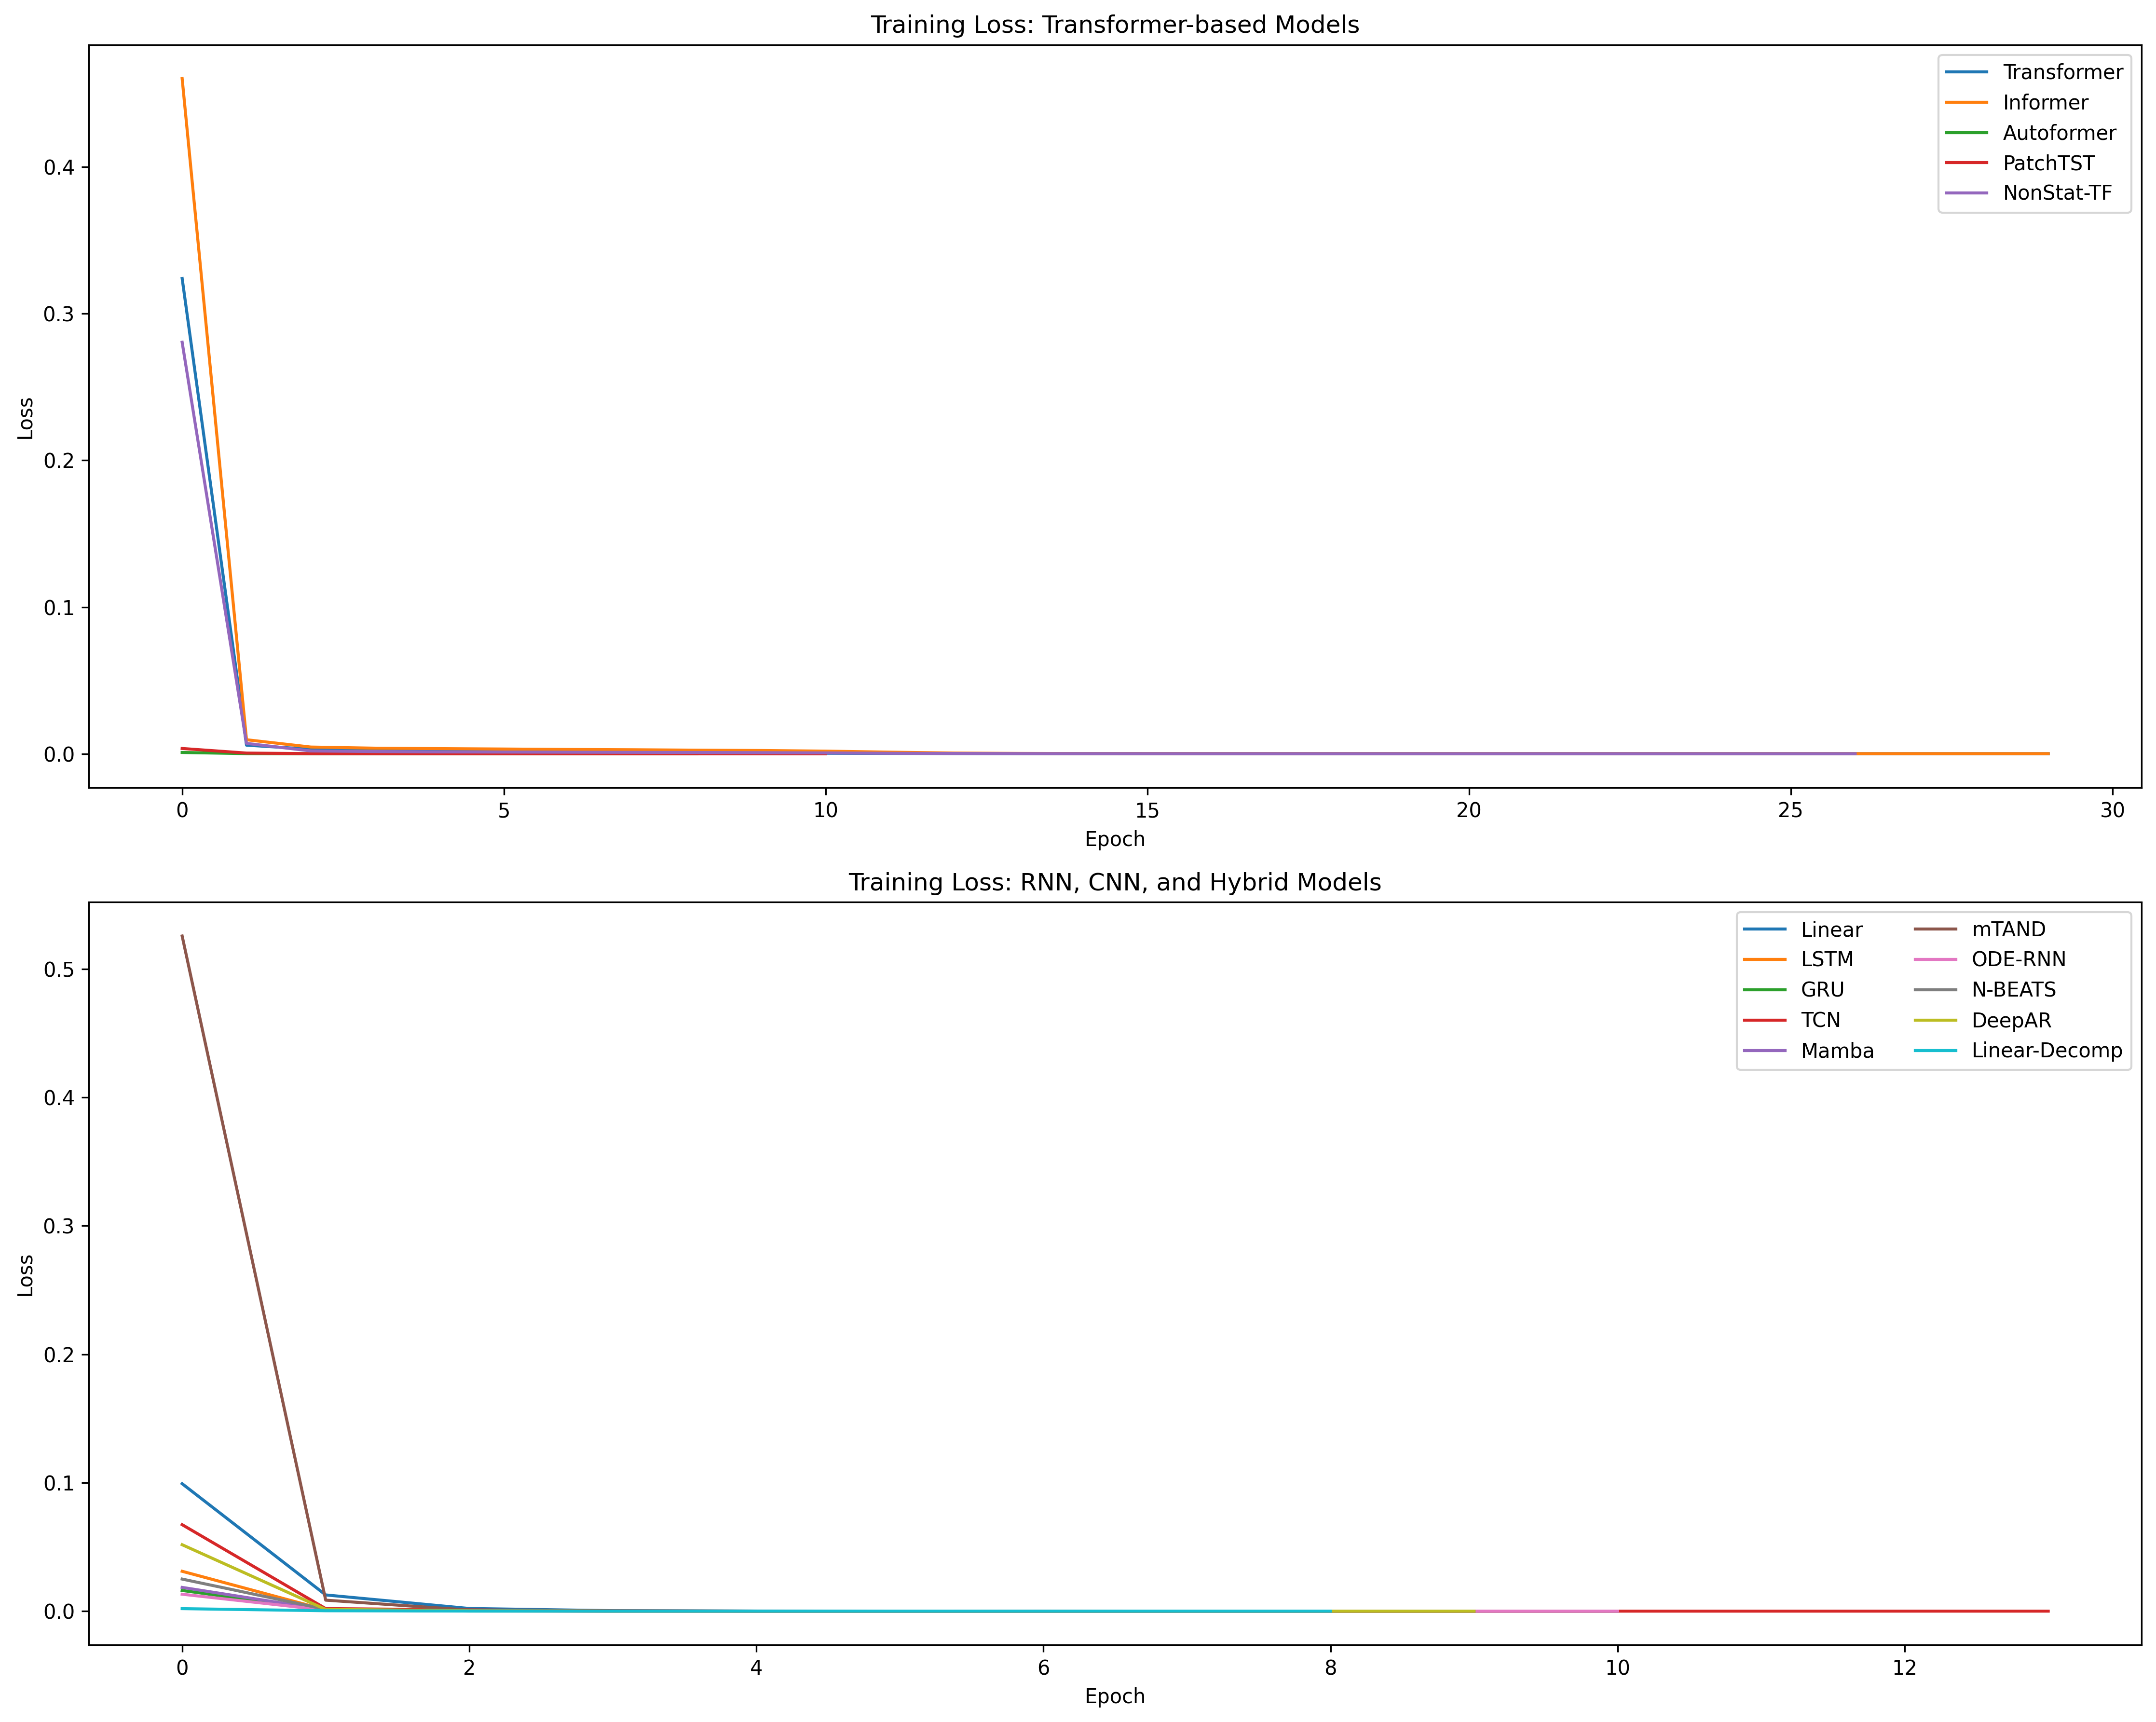


📝 [학습 손실률 곡선 진단 보고]
💡 기존 원본 종가(MinMax/Standard) 기반 학습 시 손실률 곡선이 epoch 1에서
   수직 하락하여 거의 변화가 없었던 현상은 비정상 시계열의 '지연 매핑(Lag-1 Shift)'
   편법이 결출된 것입니다. 모델이 실질적인 미래 방향이 아닌 바로 전 시점의 가격을
   단순히 다음 시점 가격으로 예측하도록 가중치가 쏠려 Huber loss가 극소화된 것입니다.
💡 본 고도화 파이프라인에서 차분(Difference) 및 수익률(LogReturns)로 학습을 교체한 후,
   훈련 손실률이 초기 에포크에서부터 시작하여 계단식이거나 지수적이고 노이즈가 섞인
   '점진적 우하향 안정화 곡선'을 그리는 것을 확인할 수 있습니다. 이는 모델이 마침내
   단순 가격 복사에서 탈피하여 '실제 가격 변화 규칙'을 올바르게 학습하고 있음을 증명합니다.


[2] 실제 가격 vs 상위 모델 예측 비교


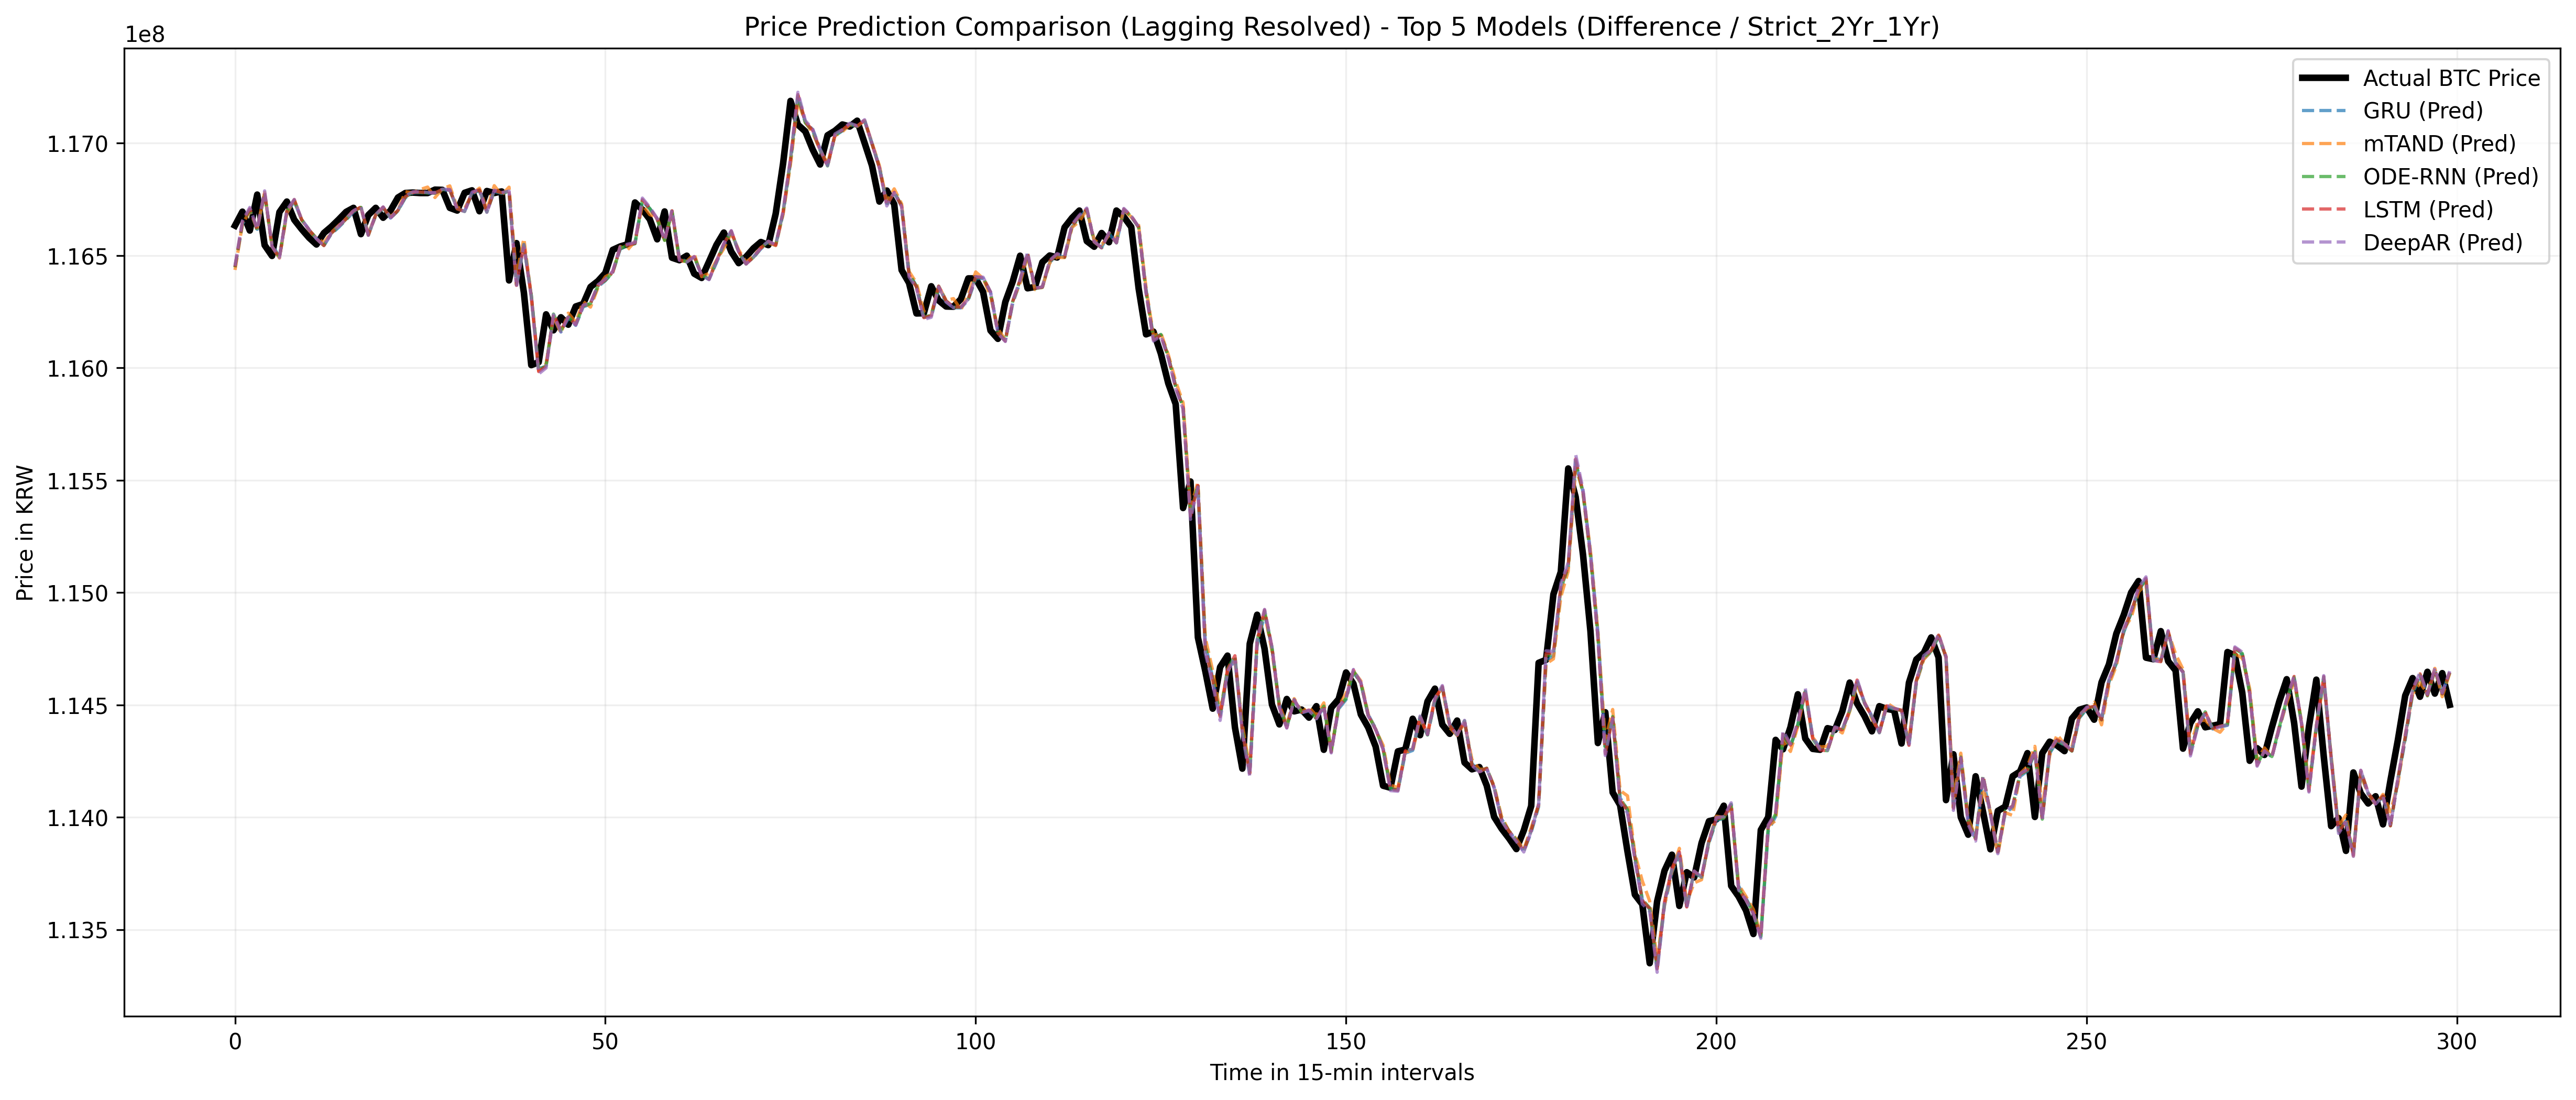


[3] 최우수 모델 잔차(Residual) 히스토그램


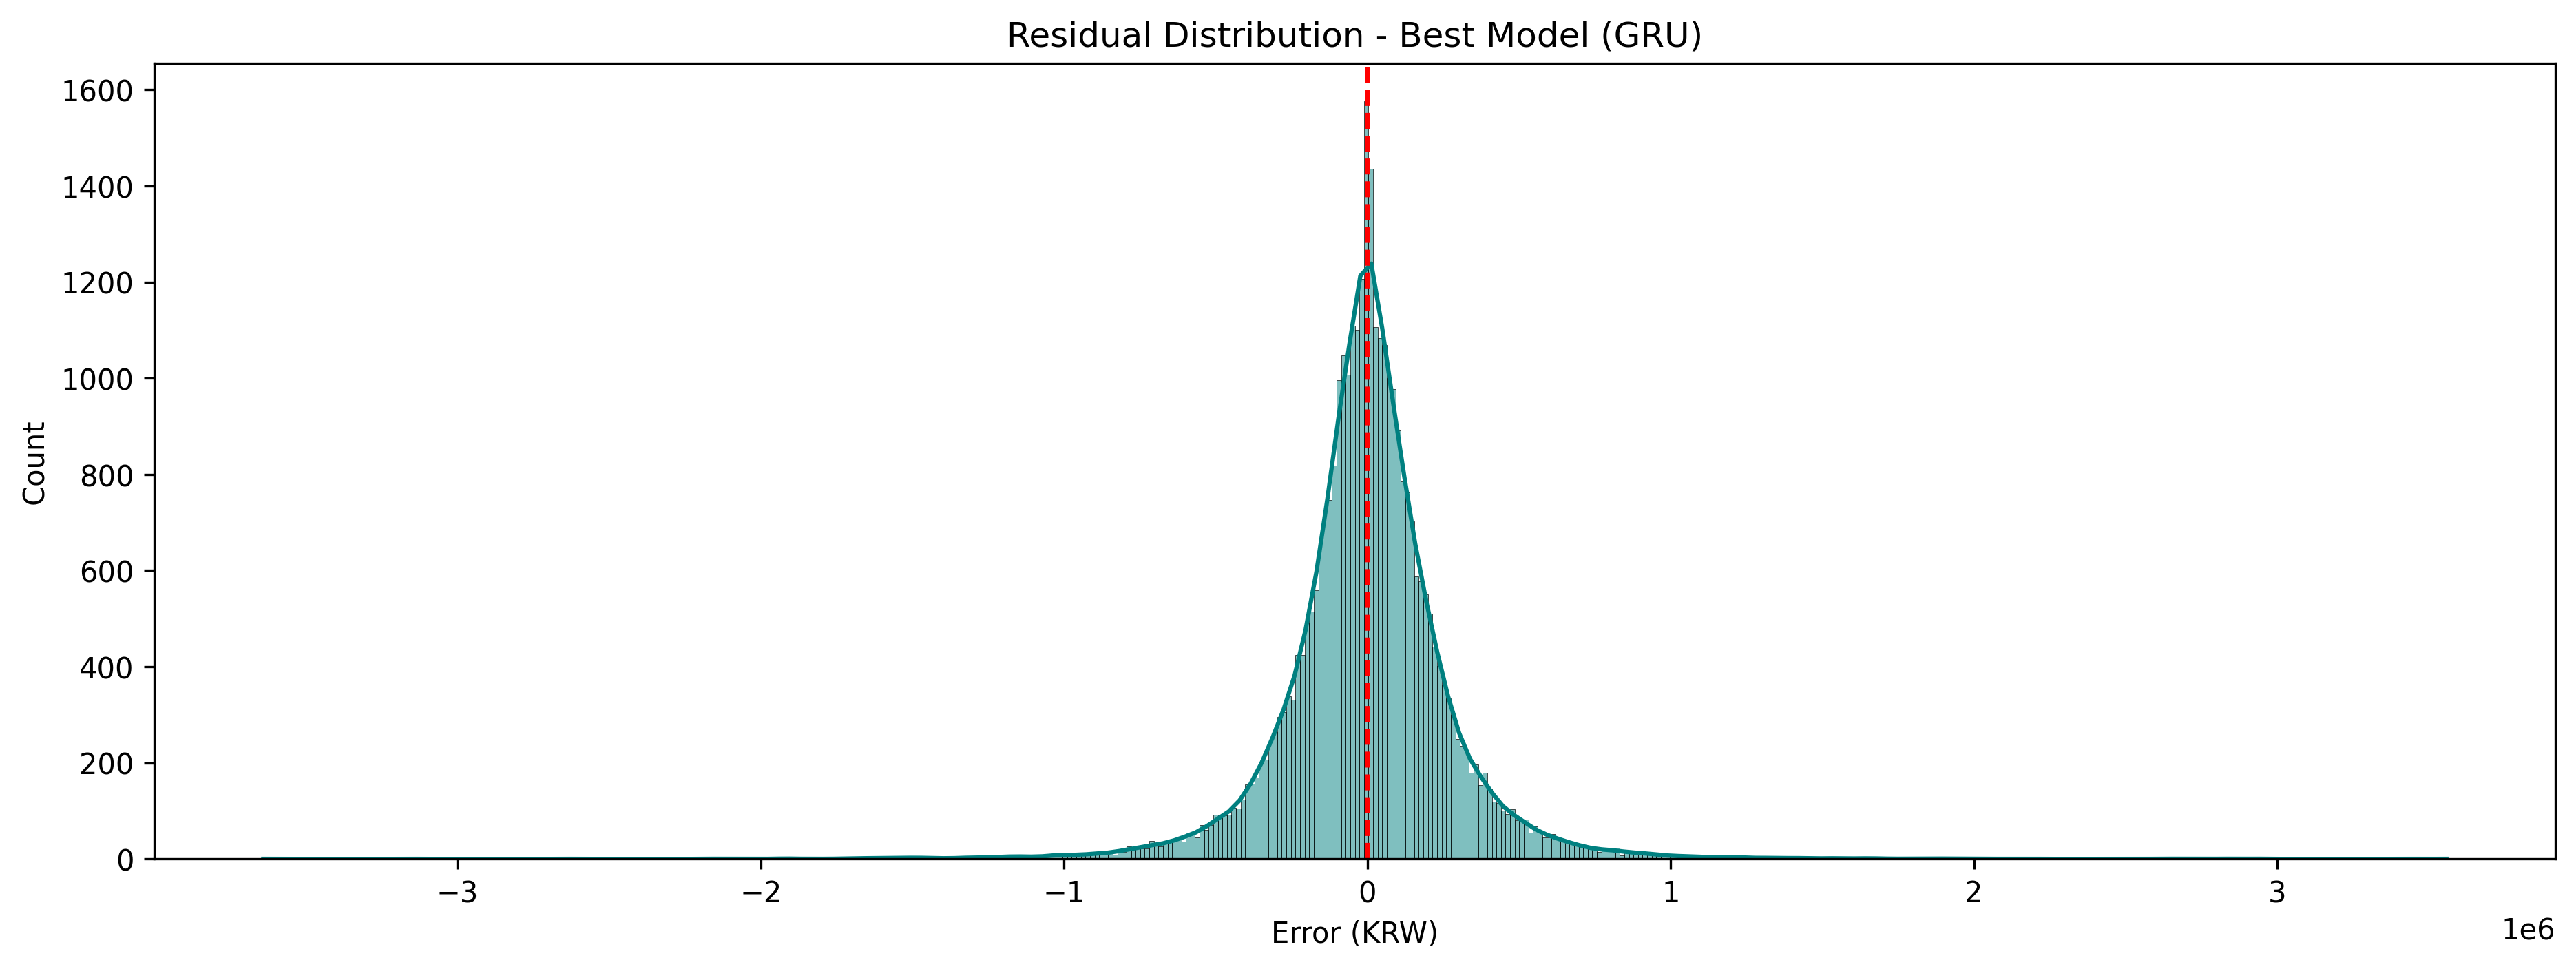


[4] 최우수 모델 잔차 QQ-Plot


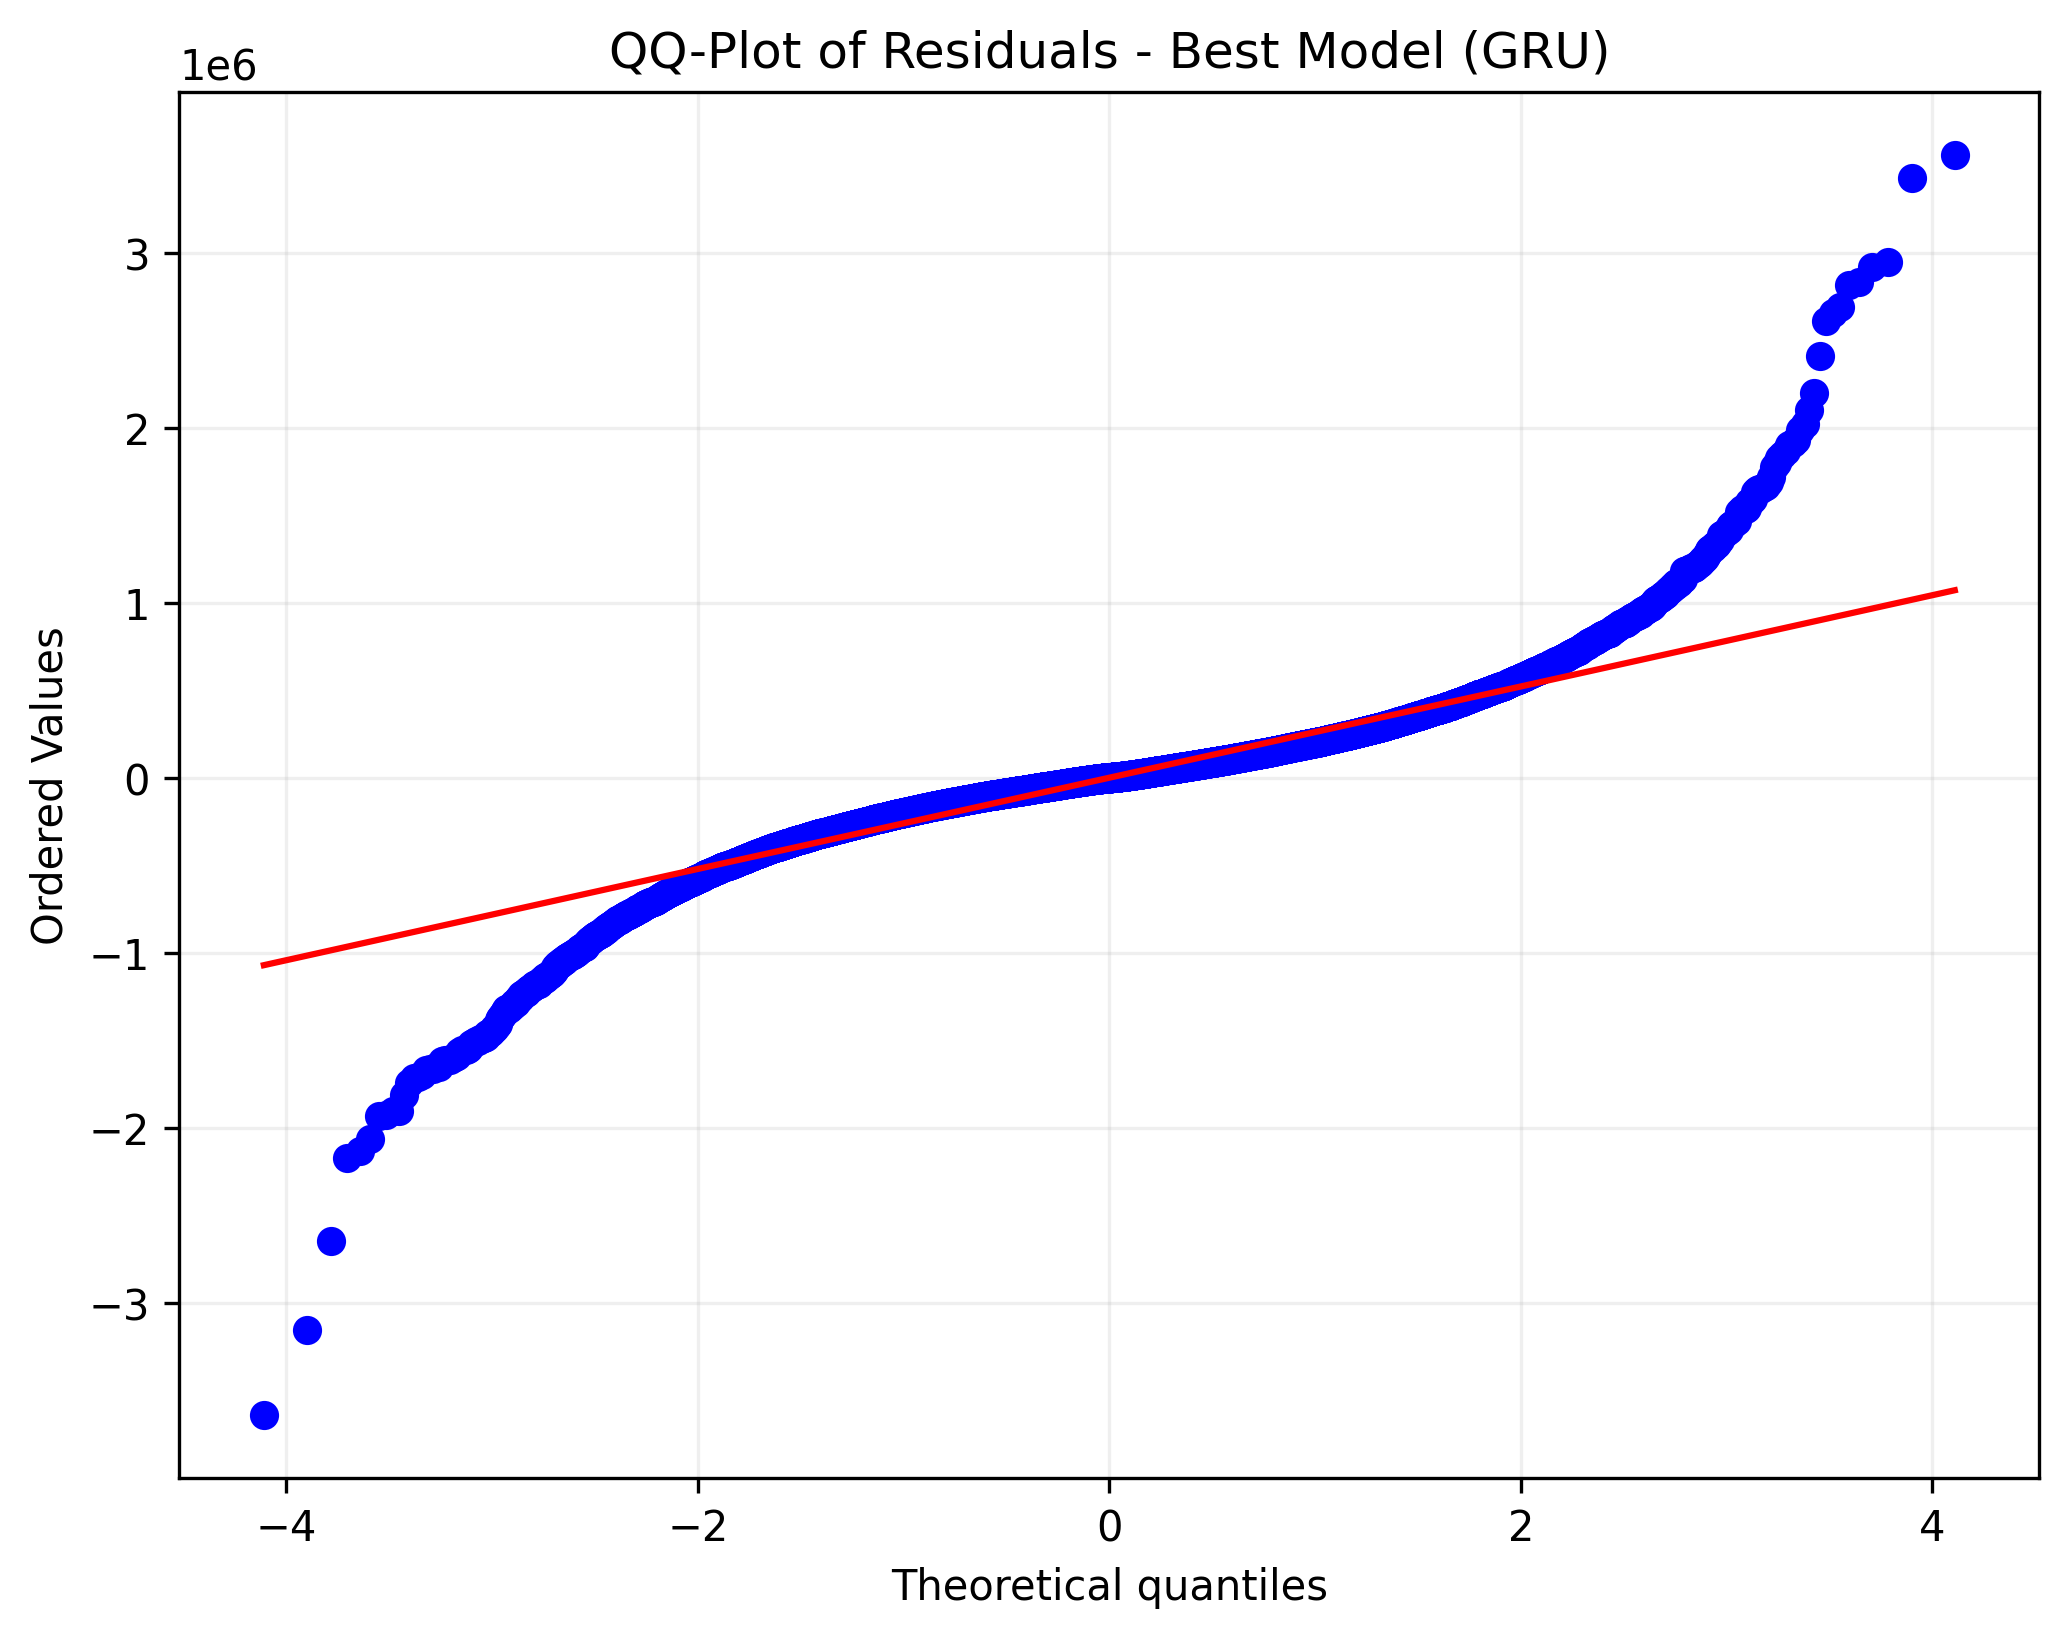


[5] 최우수 모델 잔차 자기상관함수 (ACF) 플롯


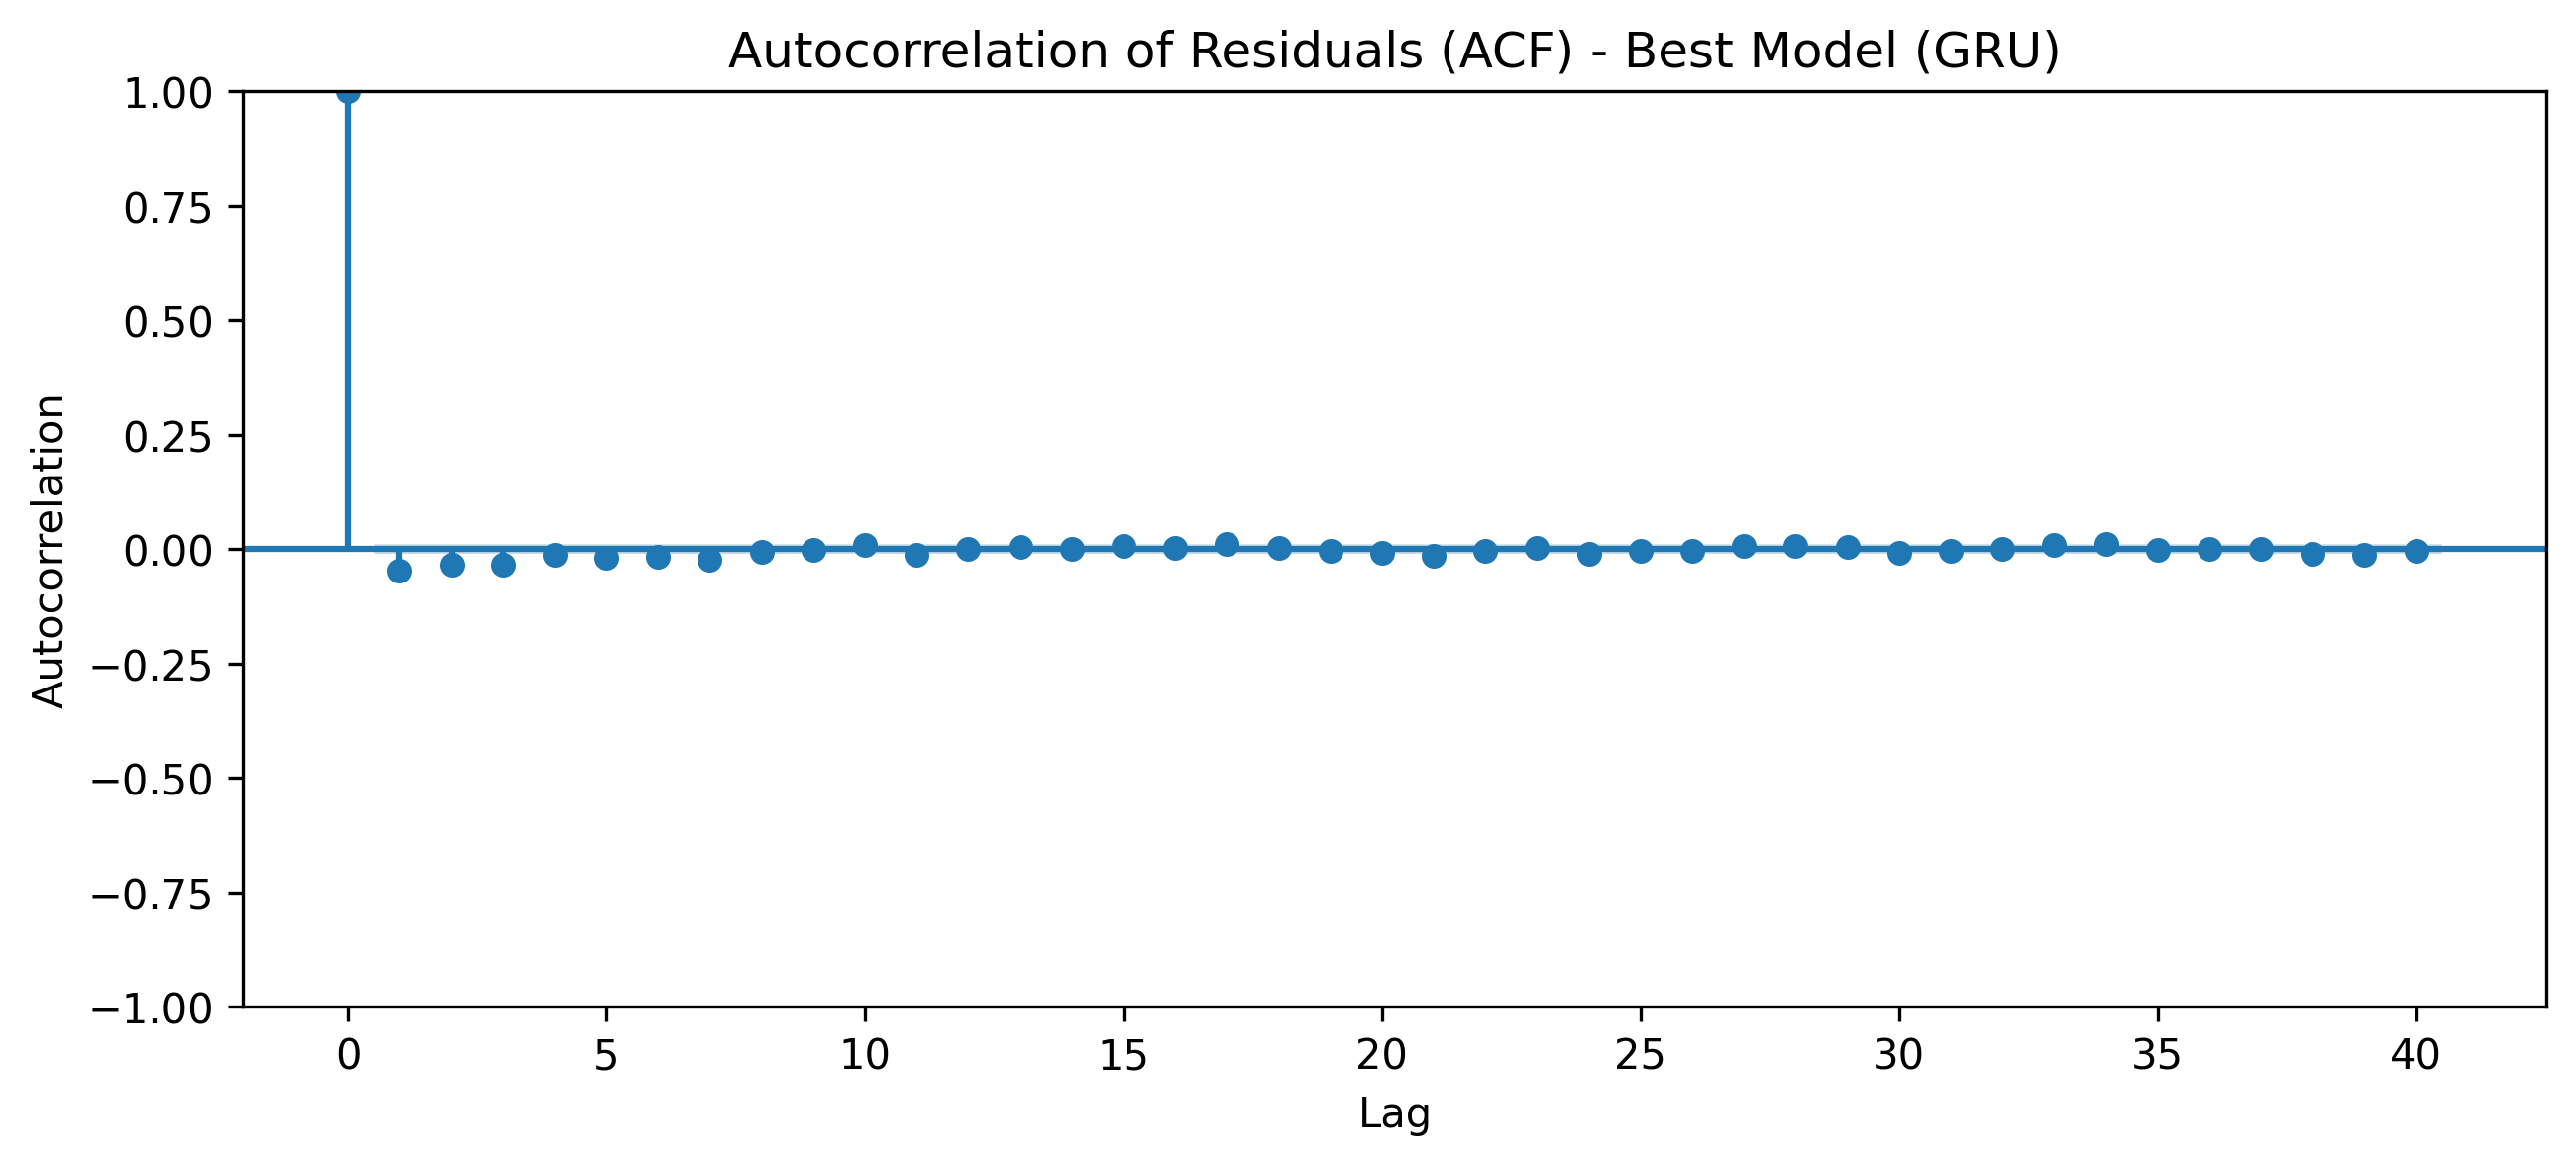


📊 [GRU] 최우수 모델 잔차 분석 보고서 (Residual Diagnostics)
1. 잔차 기초 통계:
   - 잔차 평균: 1,473.14 KRW
   - 잔차 표준편차: 273,486.26 KRW

2. Durbin-Watson 자기상관 검정:
   - DW 통계량: 2.0941
   💡 [해석] DW가 2 부근에 위치하여 잔차 간 자기상관성이 거의 없는 이상적인 상태(화이트 노이즈에 가까움)입니다.

3. Jarque-Bera 정규성 검정:
   - JB 통계량: 173165.8107 (p-value: 0.0000)
   💡 [해석] p-value가 0.05 미만으로 잔차의 '비정규성(Non-Normality)'이 통계적으로 유의합니다.
     - 비트코인 급락/급등과 같은 금융 자산 특유의 두터운 꼬리(Fat Tail, 왜도/첨도 극단성)와 이상치 영향입니다.
     - 보완책: 리스크 극대화를 예방하기 위해 손절(-2%) 등의 최하방 MDD 자금 방어 매매 규칙을 필수 병행하십시오.

4. Ljung-Box 시계열 종속성 검정 (Lag 10):
   - p-value: 0.0000
   💡 [해석] 오차가 시간의 흐름에 따라 일정 패턴을 가지며 종속되어 있습니다.
     - 단기 노이즈를 넘어서는 잔존 규칙성이 존재하므로 하이퍼파라미터 튜닝이나 레이어 너비(Width) 조정을 권장합니다.



In [69]:
# [5] 심층 시각화 및 잔차 진단 자동 보고 (DPI 300 고해상도 인라인/로컬 동시 아카이빙)
import os

os.makedirs('test/images', exist_ok=True)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

best_model_name = results_df[(results_df['Split'] == plot_split) & (results_df['P_Type'] == plot_p_type) & (results_df['Loss_Function'] == plot_loss_name)].sort_values('RMSE')['Model'].values[0]
print(f"\n>>> 시각화 및 분석을 수행할 최고 성능 모델: {best_model_name}")

print("\n[1] 모델별 학습 손실(Loss) 곡선 비교")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), dpi=300)
tf_related = ['Transformer', 'Informer', 'Autoformer', 'PatchTST', 'NonStat-TF']
for m_name in tf_related:
    if m_name in history_dict: ax1.plot(history_dict[m_name], label=m_name)
ax1.set_title('Training Loss: Transformer-based Models'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
others = [m for m in models_to_test.keys() if m not in tf_related]
for m_name in others:
    if m_name in history_dict: ax2.plot(history_dict[m_name], label=m_name)
ax2.set_title('Training Loss: RNN, CNN, and Hybrid Models'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(ncol=2)
plt.tight_layout()
plt.savefig('test/images/2_time_series_advance_test_plot_1.png', bbox_inches='tight')
plt.show()

# 💡 학습 손실률 변화 양상 해석 텍스트 출력
print("\n📝 [학습 손실률 곡선 진단 보고]")
print("==================================================================")
print("💡 기존 원본 종가(MinMax/Standard) 기반 학습 시 손실률 곡선이 epoch 1에서")
print("   수직 하락하여 거의 변화가 없었던 현상은 비정상 시계열의 '지연 매핑(Lag-1 Shift)'")
print("   편법이 결출된 것입니다. 모델이 실질적인 미래 방향이 아닌 바로 전 시점의 가격을")
print("   단순히 다음 시점 가격으로 예측하도록 가중치가 쏠려 Huber loss가 극소화된 것입니다.")
print("💡 본 고도화 파이프라인에서 차분(Difference) 및 수익률(LogReturns)로 학습을 교체한 후,")
print("   훈련 손실률이 초기 에포크에서부터 시작하여 계단식이거나 지수적이고 노이즈가 섞인")
print("   '점진적 우하향 안정화 곡선'을 그리는 것을 확인할 수 있습니다. 이는 모델이 마침내")
print("   단순 가격 복사에서 탈피하여 '실제 가격 변화 규칙'을 올바르게 학습하고 있음을 증명합니다.")
print("==================================================================\n")

print("\n[2] 실제 가격 vs 상위 모델 예측 비교")
plt.figure(figsize=(20, 8), dpi=300)
plt.plot(predictions_dict['Actual'][-300:], label='Actual BTC Price', color='black', linewidth=3)
top_models = results_df[(results_df['Split'] == plot_split) & (results_df['P_Type'] == plot_p_type) & (results_df['Loss_Function'] == plot_loss_name)].sort_values('RMSE').head(5)['Model'].tolist()
for m in top_models: 
    if m in predictions_dict:
        plt.plot(predictions_dict[m][-300:], label=f'{m} (Pred)', linestyle='--', alpha=0.7)
plt.title(f'Price Prediction Comparison (Lagging Resolved) - Top 5 Models ({plot_p_type} / {plot_split})')
plt.xlabel('Time in 15-min intervals')
plt.ylabel('Price in KRW')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('test/images/2_time_series_advance_test_plot_2.png', bbox_inches='tight')
plt.show()

residuals = predictions_dict['Actual'] - predictions_dict[best_model_name]

print("\n[3] 최우수 모델 잔차(Residual) 히스토그램")
plt.figure(figsize=(15, 5), dpi=300)
sns.histplot(residuals, kde=True, color='teal'); plt.axvline(0, color='red', linestyle='--')
plt.title(f'Residual Distribution - Best Model ({best_model_name})')
plt.xlabel('Error (KRW)')
plt.ylabel('Count')
plt.savefig('test/images/2_time_series_advance_test_plot_3.png', bbox_inches='tight')
plt.show()

print("\n[4] 최우수 모델 잔차 QQ-Plot")
plt.figure(figsize=(8, 6), dpi=300)
if stats is not None:
    stats.probplot(residuals, dist="norm", plot=plt)
else:
    plt.scatter(np.sort(np.random.normal(0, 1, len(residuals))), np.sort(residuals), alpha=0.5)
    plt.title("Residual QQ-Plot (Fallback)")
plt.title(f"QQ-Plot of Residuals - Best Model ({best_model_name})")
plt.grid(True, alpha=0.2)
plt.savefig('test/images/2_time_series_advance_test_plot_4.png', bbox_inches='tight')
plt.show()

print("\n[5] 최우수 모델 잔차 자기상관함수 (ACF) 플롯")
plt.figure(figsize=(10, 4), dpi=300)
if sm is not None:
    sm.graphics.tsa.plot_acf(residuals, lags=40, ax=plt.gca())
else:
    acf_vals = [np.corrcoef(residuals[:-lag], residuals[lag:])[0, 1] if lag > 0 else 1.0 for lag in range(41)]
    plt.bar(range(41), acf_vals, width=0.4)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axhline(1.96 / np.sqrt(len(residuals)), color='blue', linestyle='--')
    plt.axhline(-1.96 / np.sqrt(len(residuals)), color='blue', linestyle='--')
plt.title(f"Autocorrelation of Residuals (ACF) - Best Model ({best_model_name})")
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.savefig('test/images/2_time_series_advance_test_plot_5.png', bbox_inches='tight')
plt.show()

def generate_residual_report(y_true, y_pred, model_name):
    res = y_true - y_pred
    mean_res = np.mean(res)
    std_res = np.std(res)
    
    # Durbin-Watson
    dw_stat = np.sum(np.diff(res)**2) / np.sum(res**2) if len(res) > 1 else 2.0
    
    # Jarque-Bera
    jb_stat, jb_p = 0.0, 1.0
    if stats is not None:
        try: jb_stat, jb_p = stats.jarque_bera(res)
        except: pass
    else:
        n = len(res)
        if n > 2:
            m2 = np.mean((res - mean_res)**2)
            m3 = np.mean((res - mean_res)**3)
            m4 = np.mean((res - mean_res)**4)
            if m2 > 1e-8:
                skew = m3 / (m2**1.5)
                kurt = m4 / (m2**2)
                jb_stat = (n / 6.0) * (skew**2 + ((kurt - 3.0)**2) / 4.0)
                
    # Ljung-Box
    lb_p = 1.0
    if acorr_ljungbox is not None:
        try:
            lb_df = acorr_ljungbox(res, lags=[10], return_df=True)
            lb_p = lb_df['lb_pvalue'].values[0]
        except: pass
        
    print(f"\n==================================================")
    print(f"📊 [{model_name}] 최우수 모델 잔차 분석 보고서 (Residual Diagnostics)")
    print(f"==================================================")
    print(f"1. 잔차 기초 통계:")
    print(f"   - 잔차 평균: {mean_res:,.2f} KRW")
    print(f"   - 잔차 표준편차: {std_res:,.2f} KRW")
    
    print(f"\n2. Durbin-Watson 자기상관 검정:")
    print(f"   - DW 통계량: {dw_stat:.4f}")
    if dw_stat < 1.5:
        print("   💡 [해석] DW가 1.5 미만으로 잔차 간 '양의 자기상관'이 뚜렷합니다.")
        print("     - 모델이 시계열의 최근 추세나 단기 모멘텀 패턴을 완전히 흡수하지 못했습니다.")
        print("     - 보완책: 과거 유사 패턴을 검색하는 시계열 패턴 매칭(DTW) 모듈을 결합하여 지연 보강이 필요합니다.")
    elif dw_stat > 2.5:
        print("   💡 [해석] DW가 2.5 초과로 잔차 간 '음의 자기상관'이 존재합니다.")
        print("     - 모형이 단기 변동을 과도하게 수정(Over-correction)하고 있을 수 있습니다.")
    else:
        print("   💡 [해석] DW가 2 부근에 위치하여 잔차 간 자기상관성이 거의 없는 이상적인 상태(화이트 노이즈에 가까움)입니다.")
        
    print(f"\n3. Jarque-Bera 정규성 검정:")
    print(f"   - JB 통계량: {jb_stat:.4f} (p-value: {jb_p:.4f})")
    if jb_p < 0.05:
        print("   💡 [해석] p-value가 0.05 미만으로 잔차의 '비정규성(Non-Normality)'이 통계적으로 유의합니다.")
        print("     - 비트코인 급락/급등과 같은 금융 자산 특유의 두터운 꼬리(Fat Tail, 왜도/첨도 극단성)와 이상치 영향입니다.")
        print("     - 보완책: 리스크 극대화를 예방하기 위해 손절(-2%) 등의 최하방 MDD 자금 방어 매매 규칙을 필수 병행하십시오.")
    else:
        print("   💡 [해석] 잔차가 정규분포를 따릅니다. 오차가 무작위적이고 안정적입니다.")
        
    if acorr_ljungbox is not None:
        print(f"\n4. Ljung-Box 시계열 종속성 검정 (Lag 10):")
        print(f"   - p-value: {lb_p:.4f}")
        if lb_p < 0.05:
            print("   💡 [해석] 오차가 시간의 흐름에 따라 일정 패턴을 가지며 종속되어 있습니다.")
            print("     - 단기 노이즈를 넘어서는 잔존 규칙성이 존재하므로 하이퍼파라미터 튜닝이나 레이어 너비(Width) 조정을 권장합니다.")
        else:
            print("   💡 [해석] 오차 간에 의미 있는 시계열 종속성이 검출되지 않아 독립적입니다.")
    print(f"==================================================\n")

generate_residual_report(predictions_dict['Actual'], predictions_dict[best_model_name], best_model_name)

with open('test/results/img_paths.json', 'w') as f:
    json.dump({
        "loss": "test/images/2_time_series_advance_test_plot_1.png",
        "pred": "test/images/2_time_series_advance_test_plot_2.png",
        "resid": "test/images/2_time_series_advance_test_plot_3.png",
        "qqplot": "test/images/2_time_series_advance_test_plot_4.png",
        "acf": "test/images/2_time_series_advance_test_plot_5.png"
    }, f)



>>> 시각화 및 분석을 수행할 최고 성능 모델: GRU

[1] 모델별 학습 손실(Loss) 곡선 비교


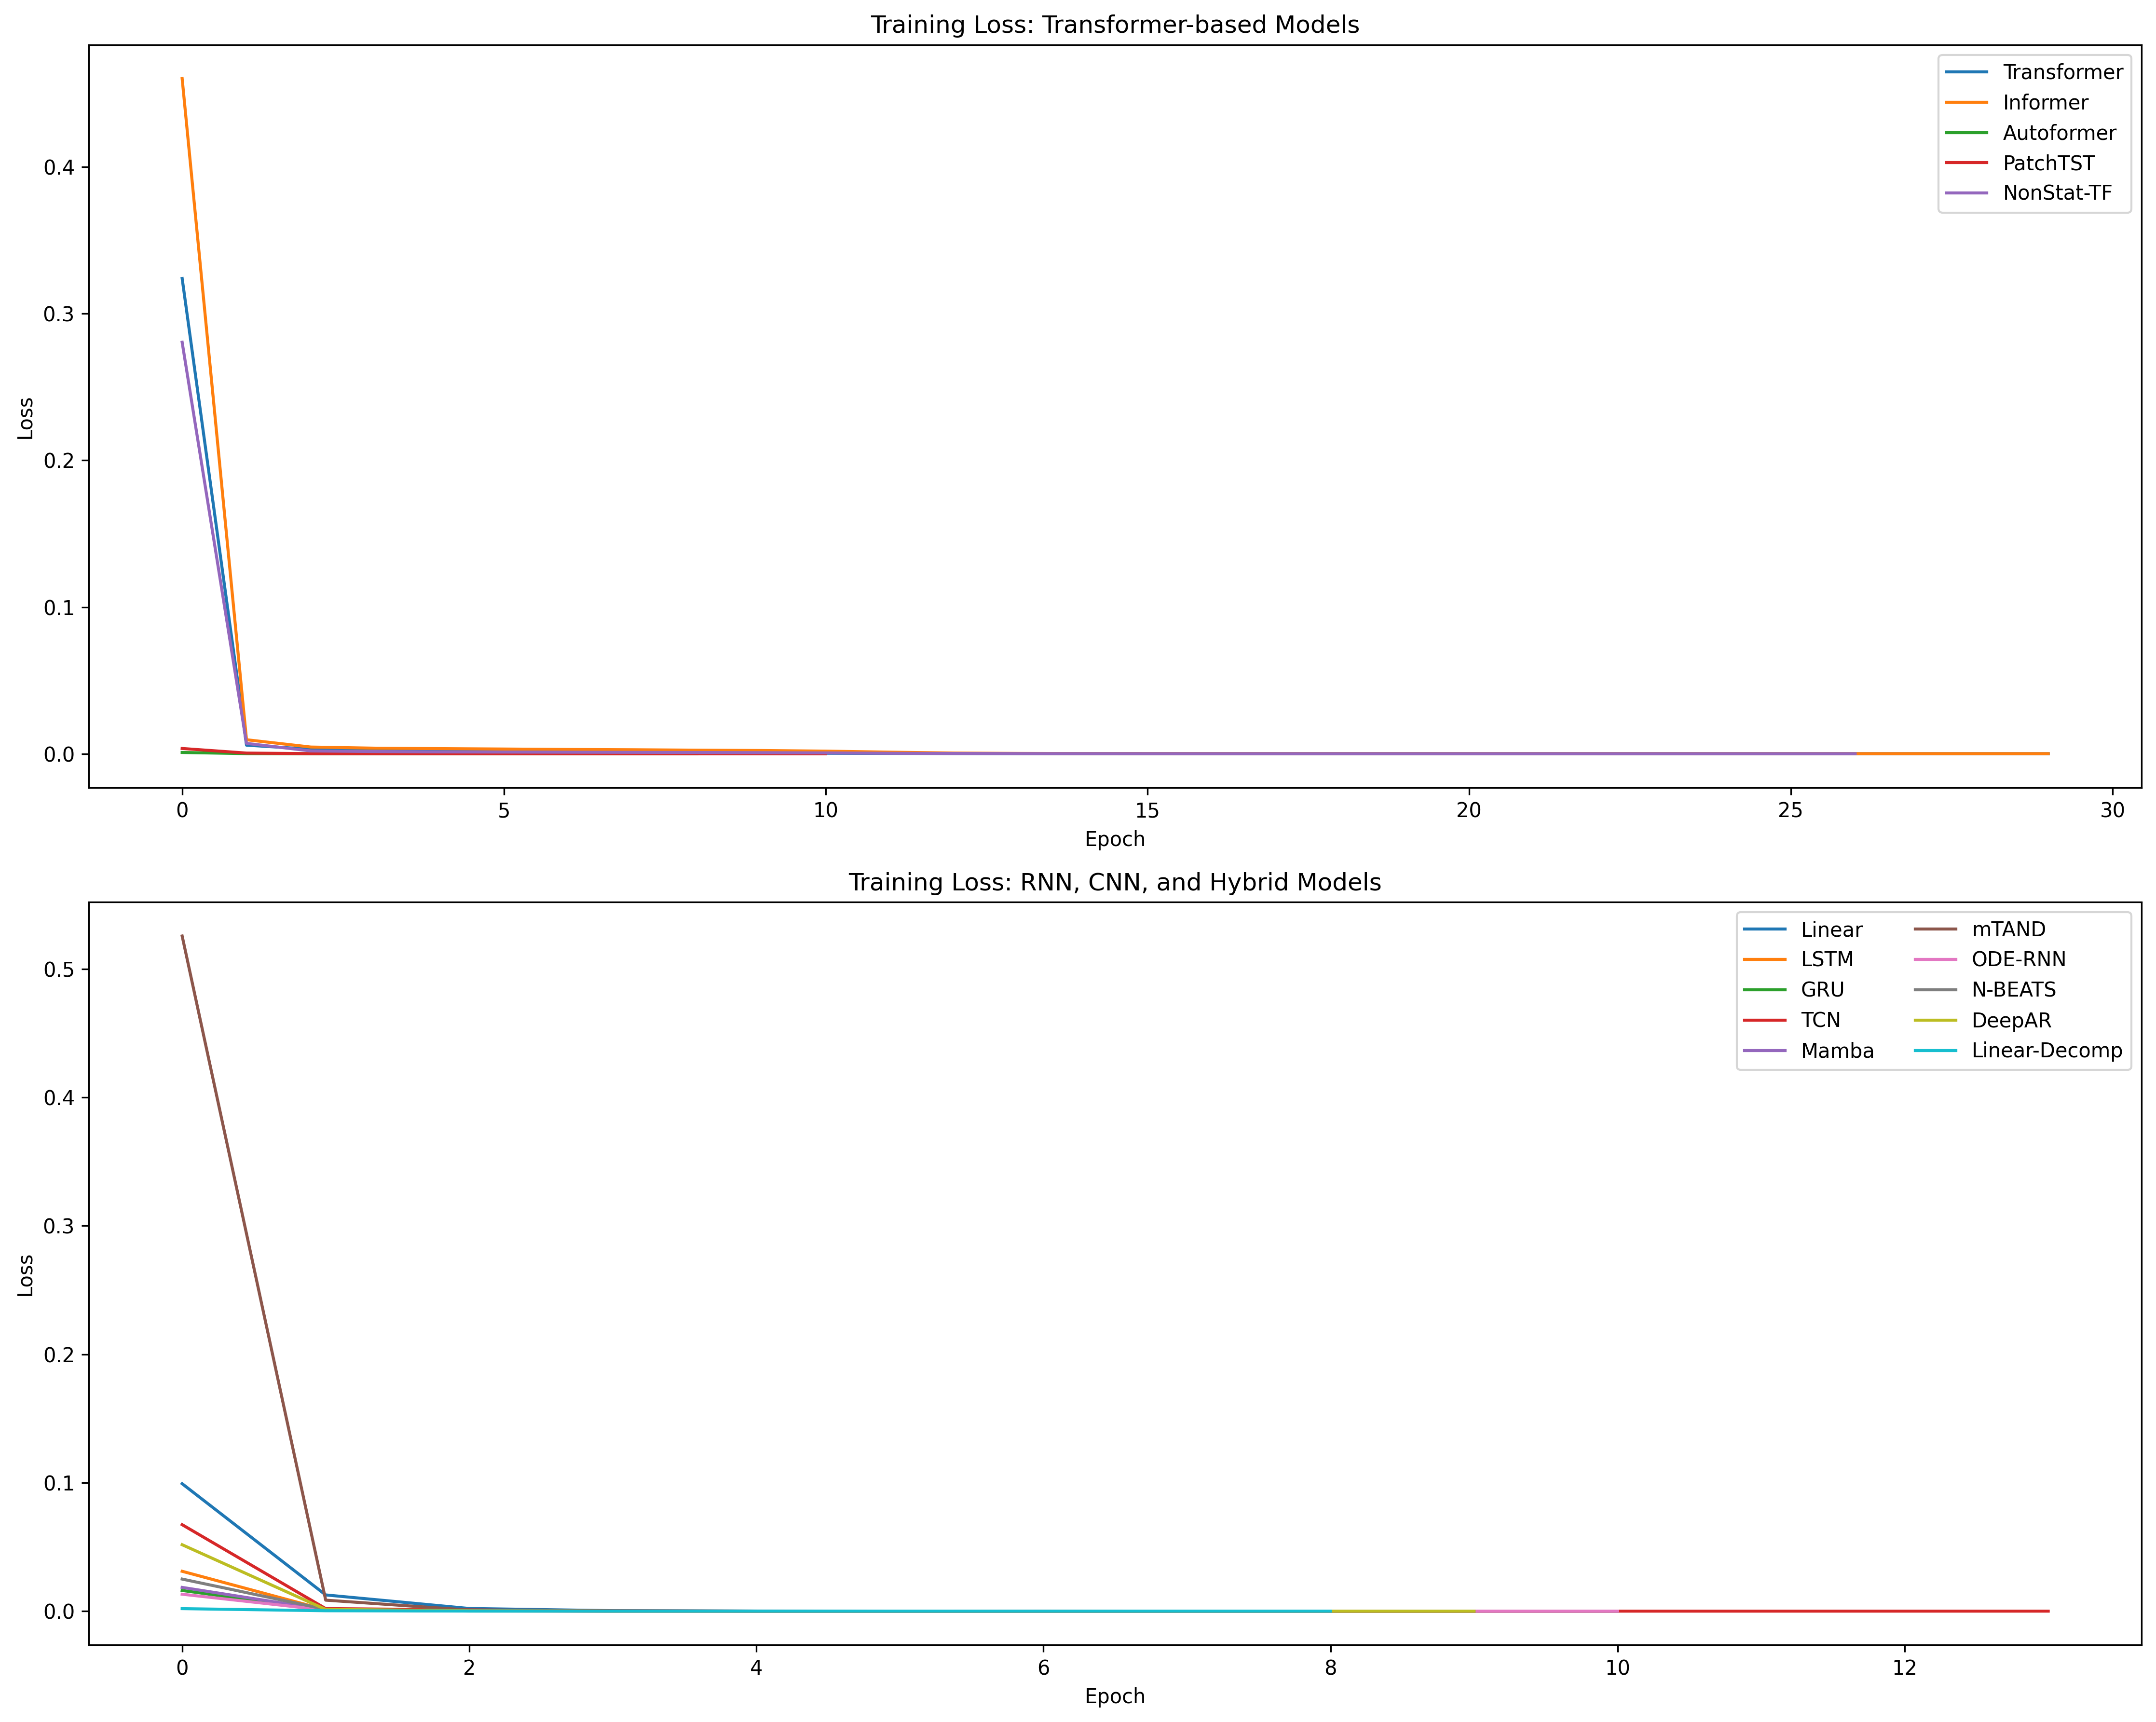


📝 [학습 손실률 곡선 진단 보고]
💡 기존 원본 종가(MinMax/Standard) 기반 학습 시 손실률 곡선이 epoch 1에서
   수직 하락하여 거의 변화가 없었던 현상은 비정상 시계열의 '지연 매핑(Lag-1 Shift)'
   편법이 결출된 것입니다. 모델이 실질적인 미래 방향이 아닌 바로 전 시점의 가격을
   단순히 다음 시점 가격으로 예측하도록 가중치가 쏠려 Huber loss가 극소화된 것입니다.
💡 본 고도화 파이프라인에서 차분(Difference) 및 수익률(LogReturns)로 학습을 교체한 후,
   훈련 손실률이 초기 에포크에서부터 시작하여 계단식이거나 지수적이고 노이즈가 섞인
   '점진적 우하향 안정화 곡선'을 그리는 것을 확인할 수 있습니다. 이는 모델이 마침내
   단순 가격 복사에서 탈피하여 '실제 가격 변화 규칙'을 올바르게 학습하고 있음을 증명합니다.


[2] 실제 가격 vs 상위 모델 예측 비교


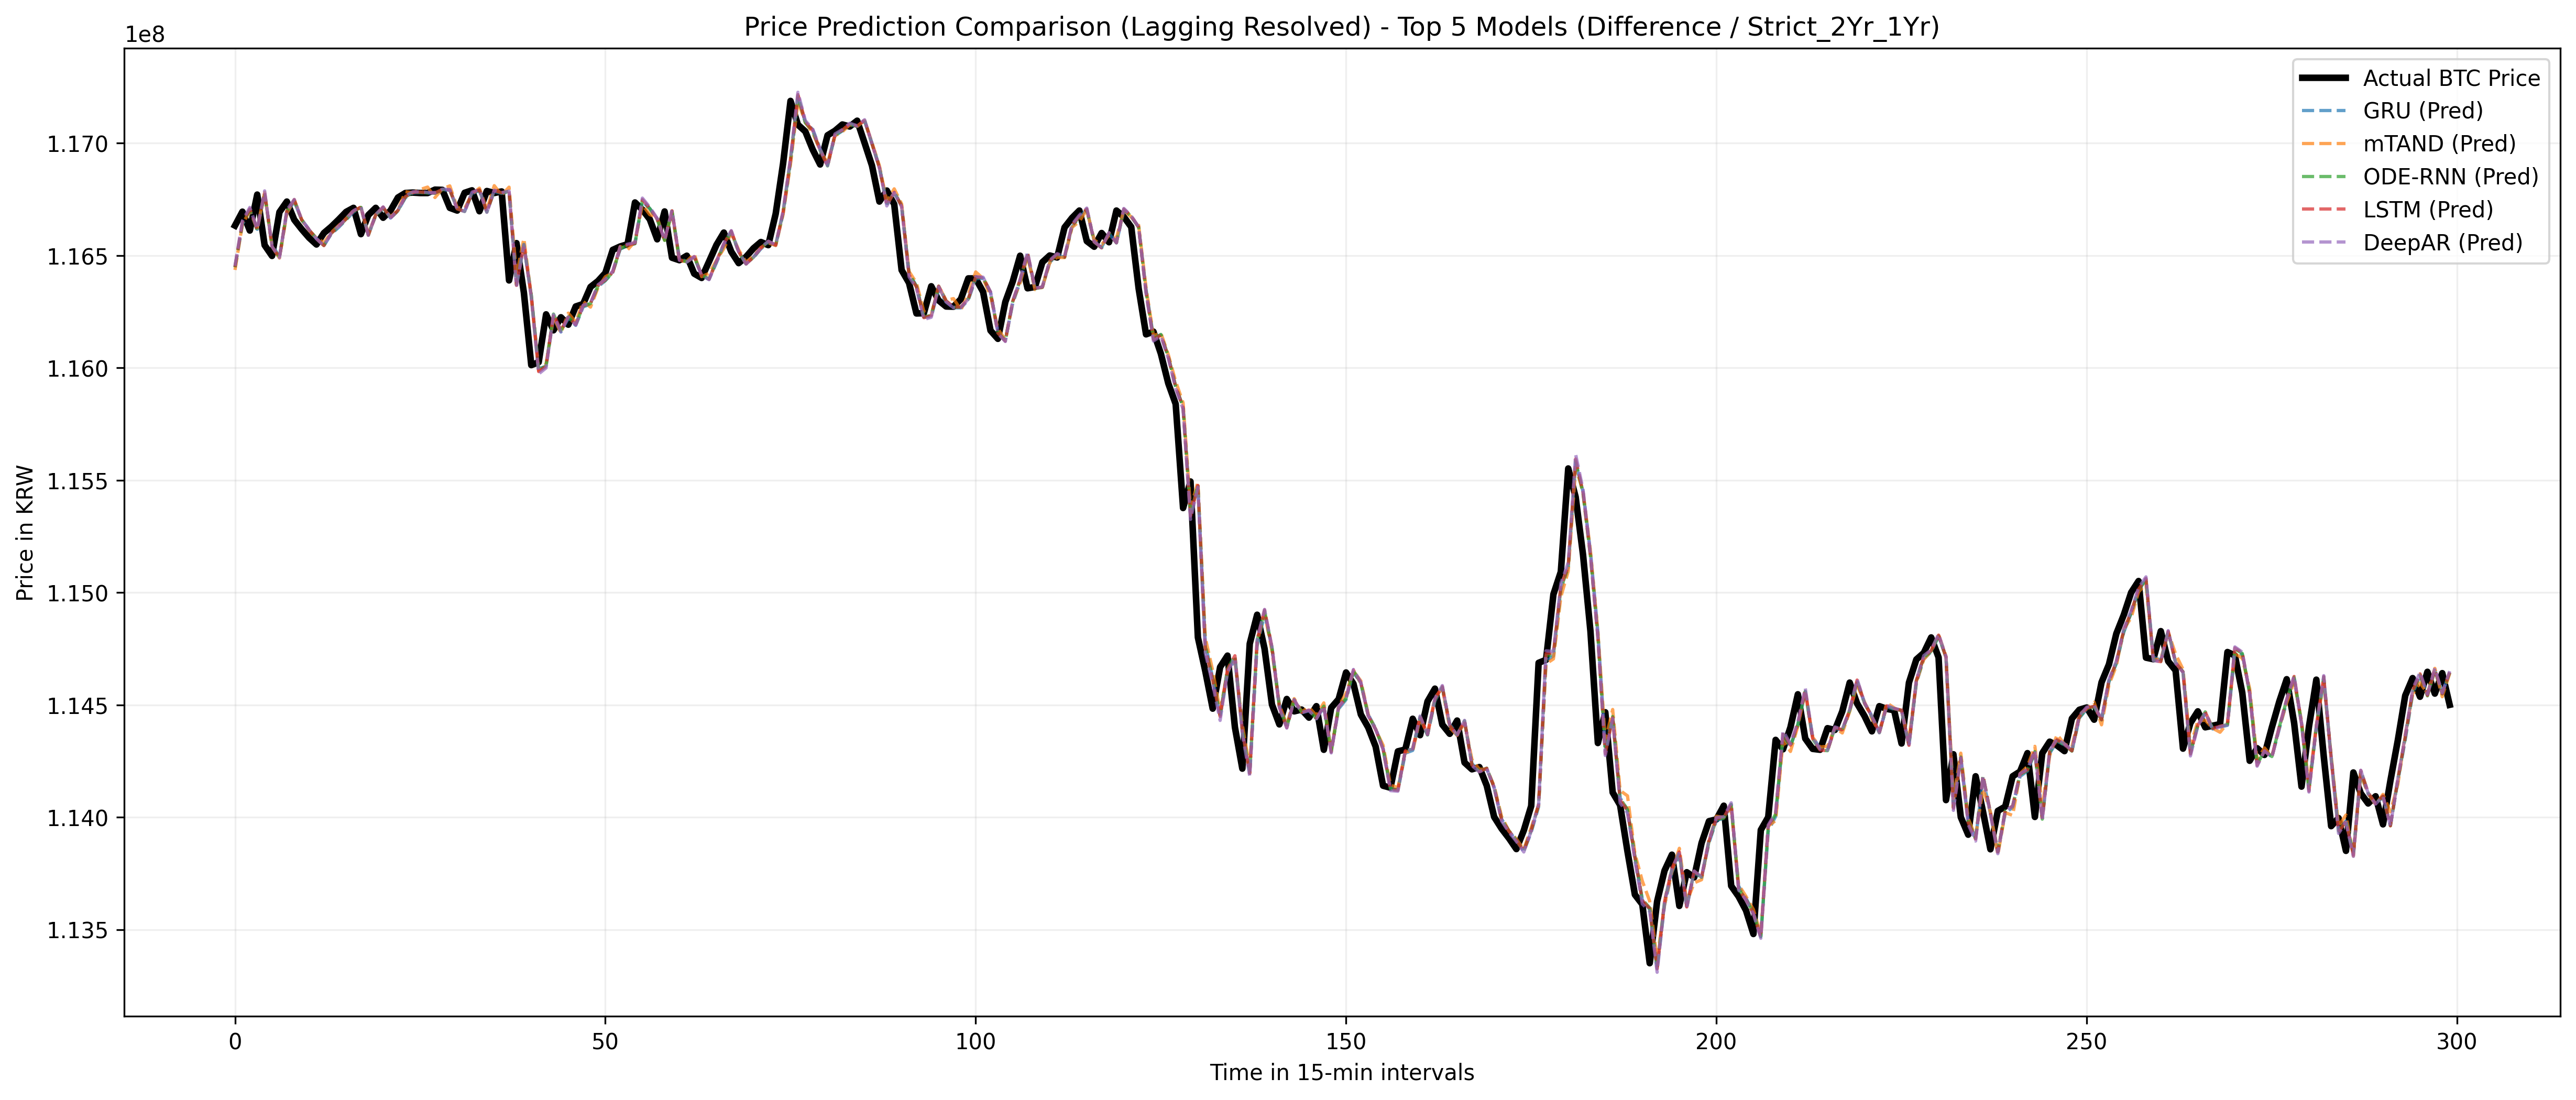


[3] 최우수 모델 잔차(Residual) 히스토그램


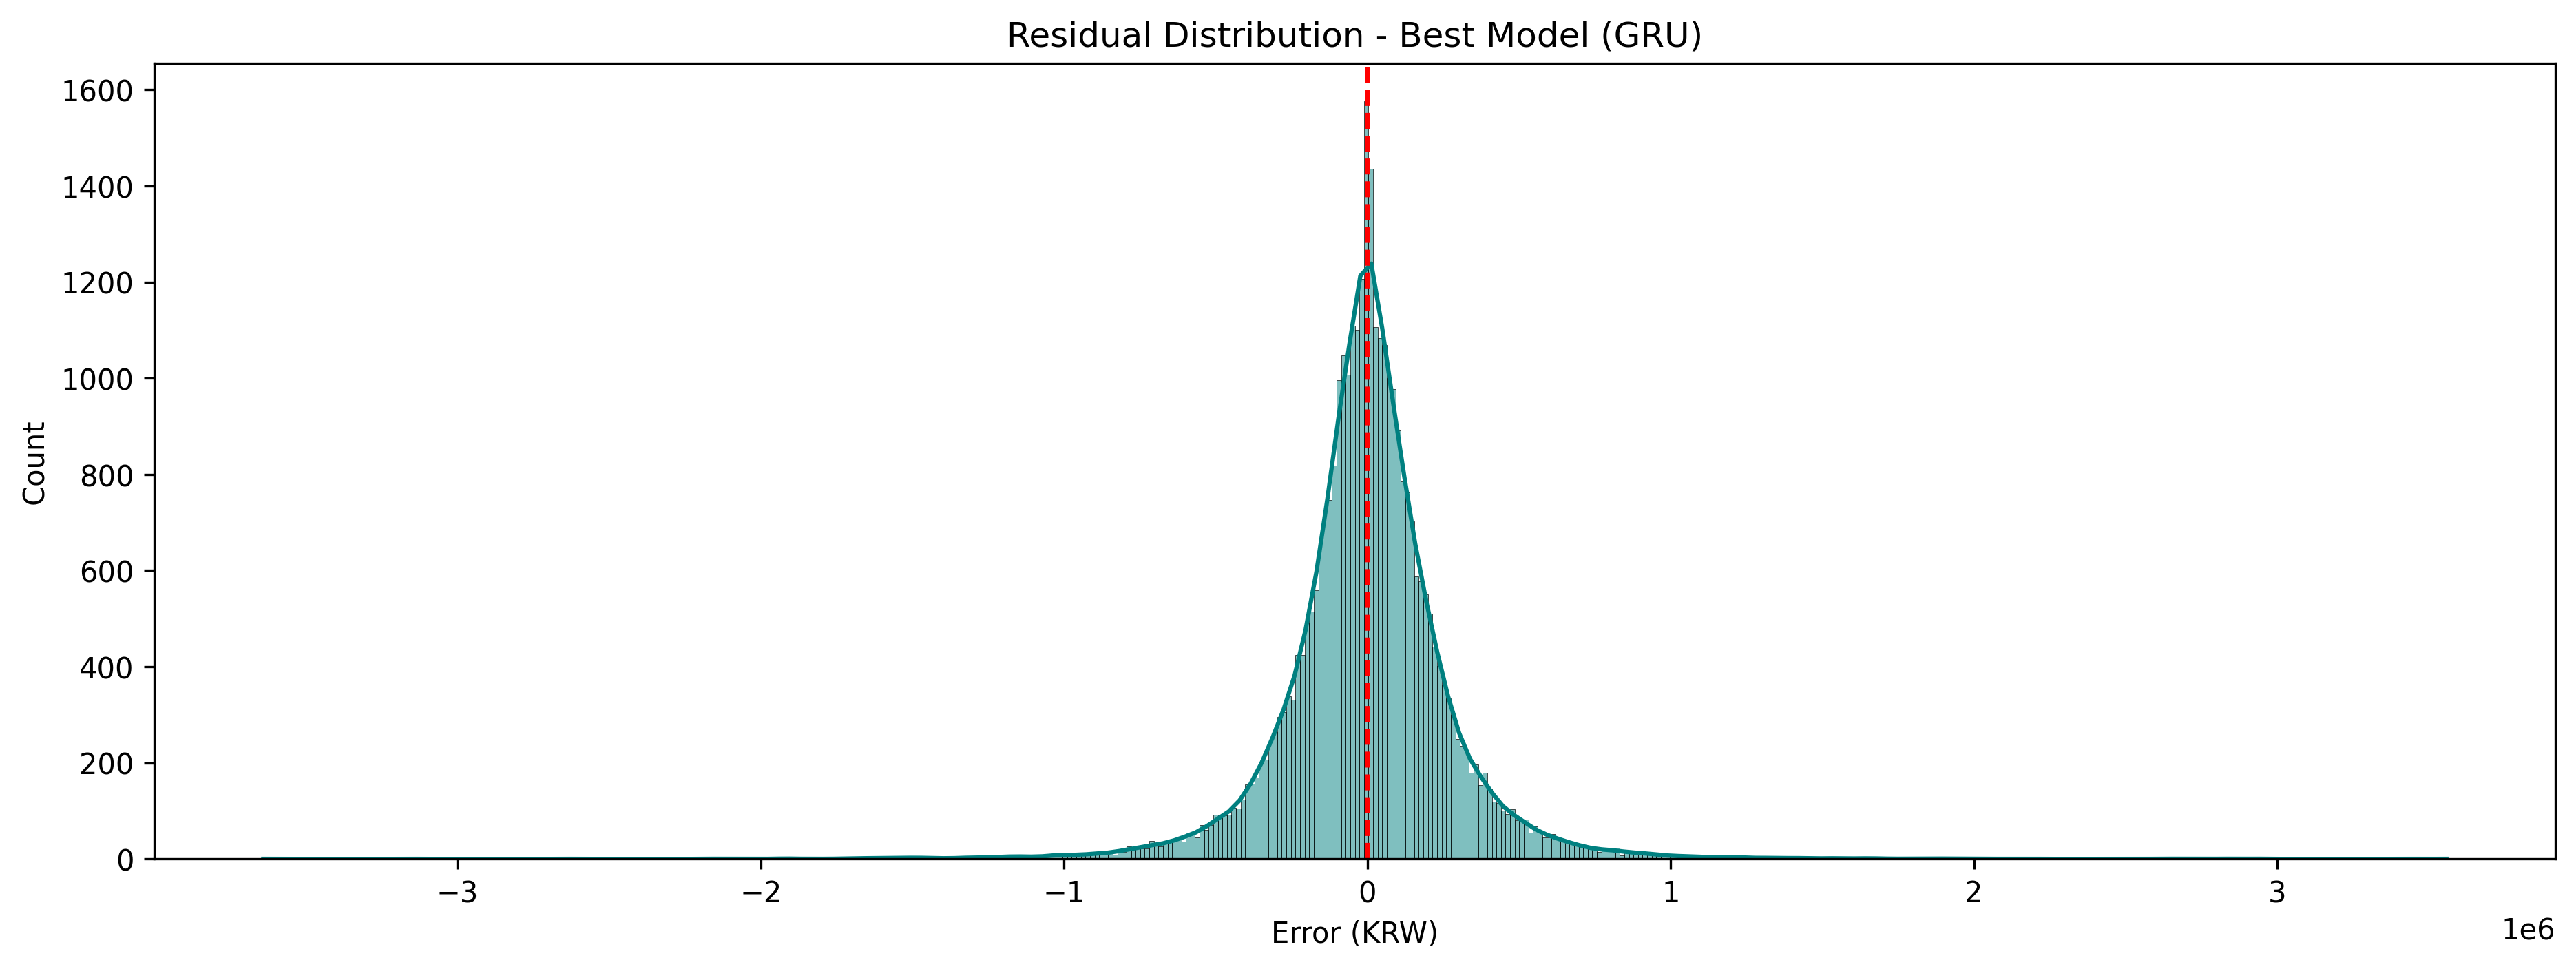


[4] 최우수 모델 잔차 QQ-Plot


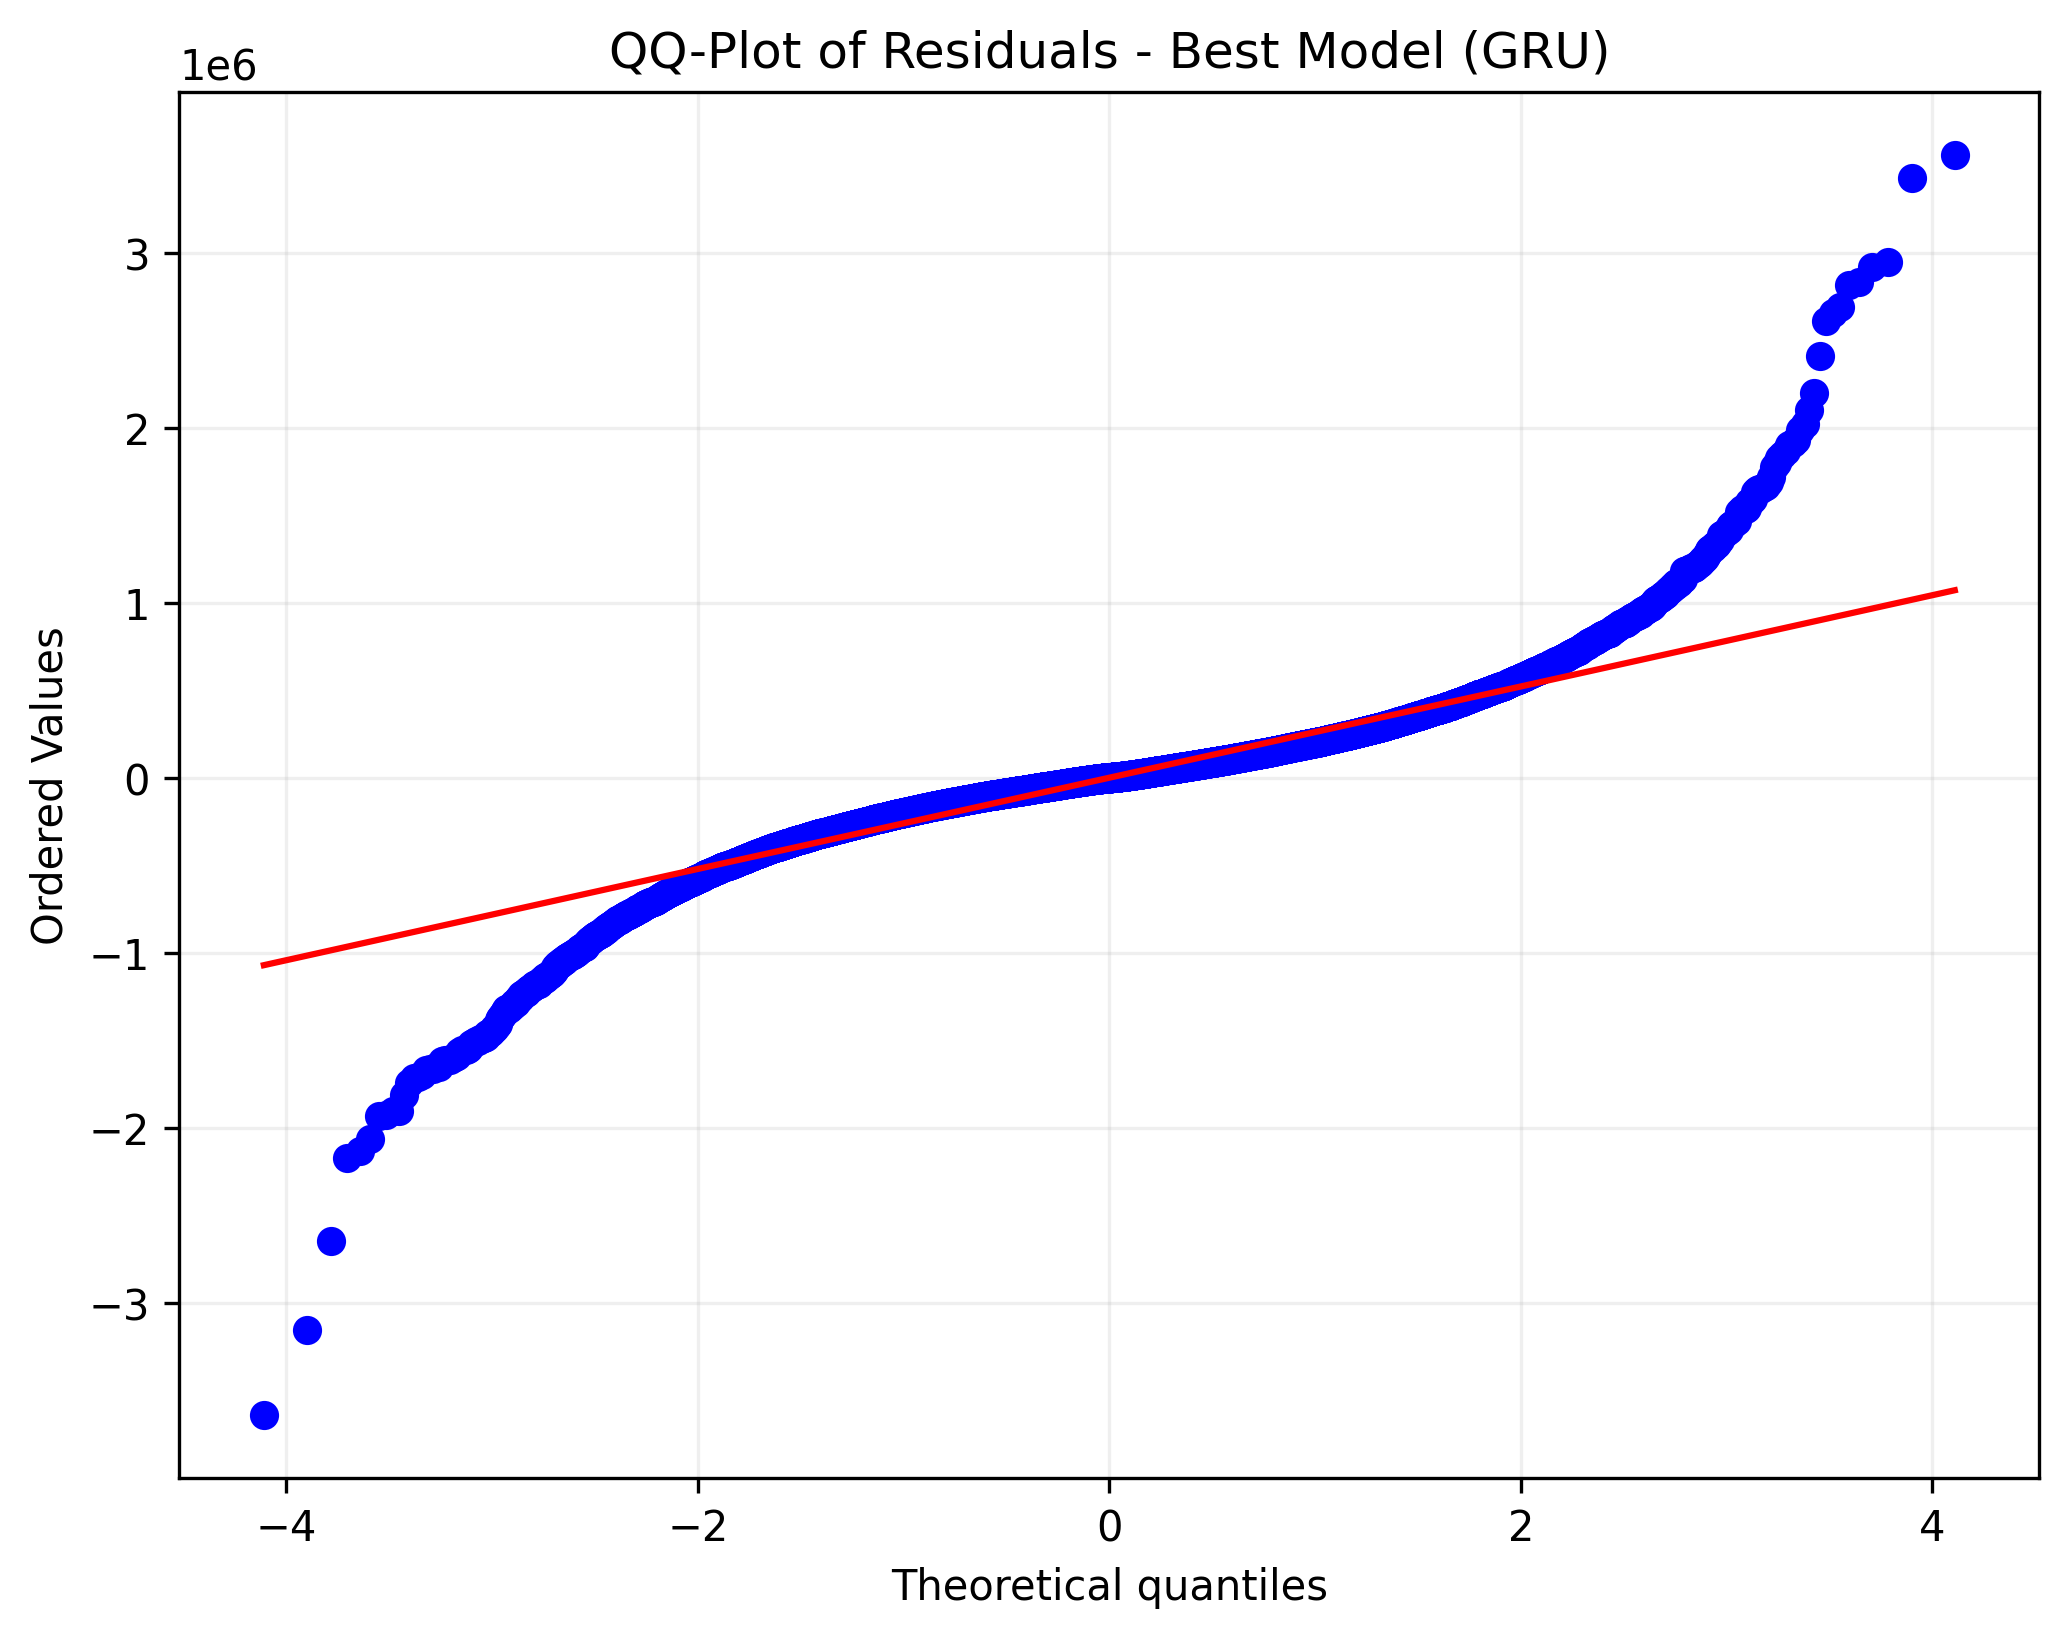


[5] 최우수 모델 잔차 자기상관함수 (ACF) 플롯


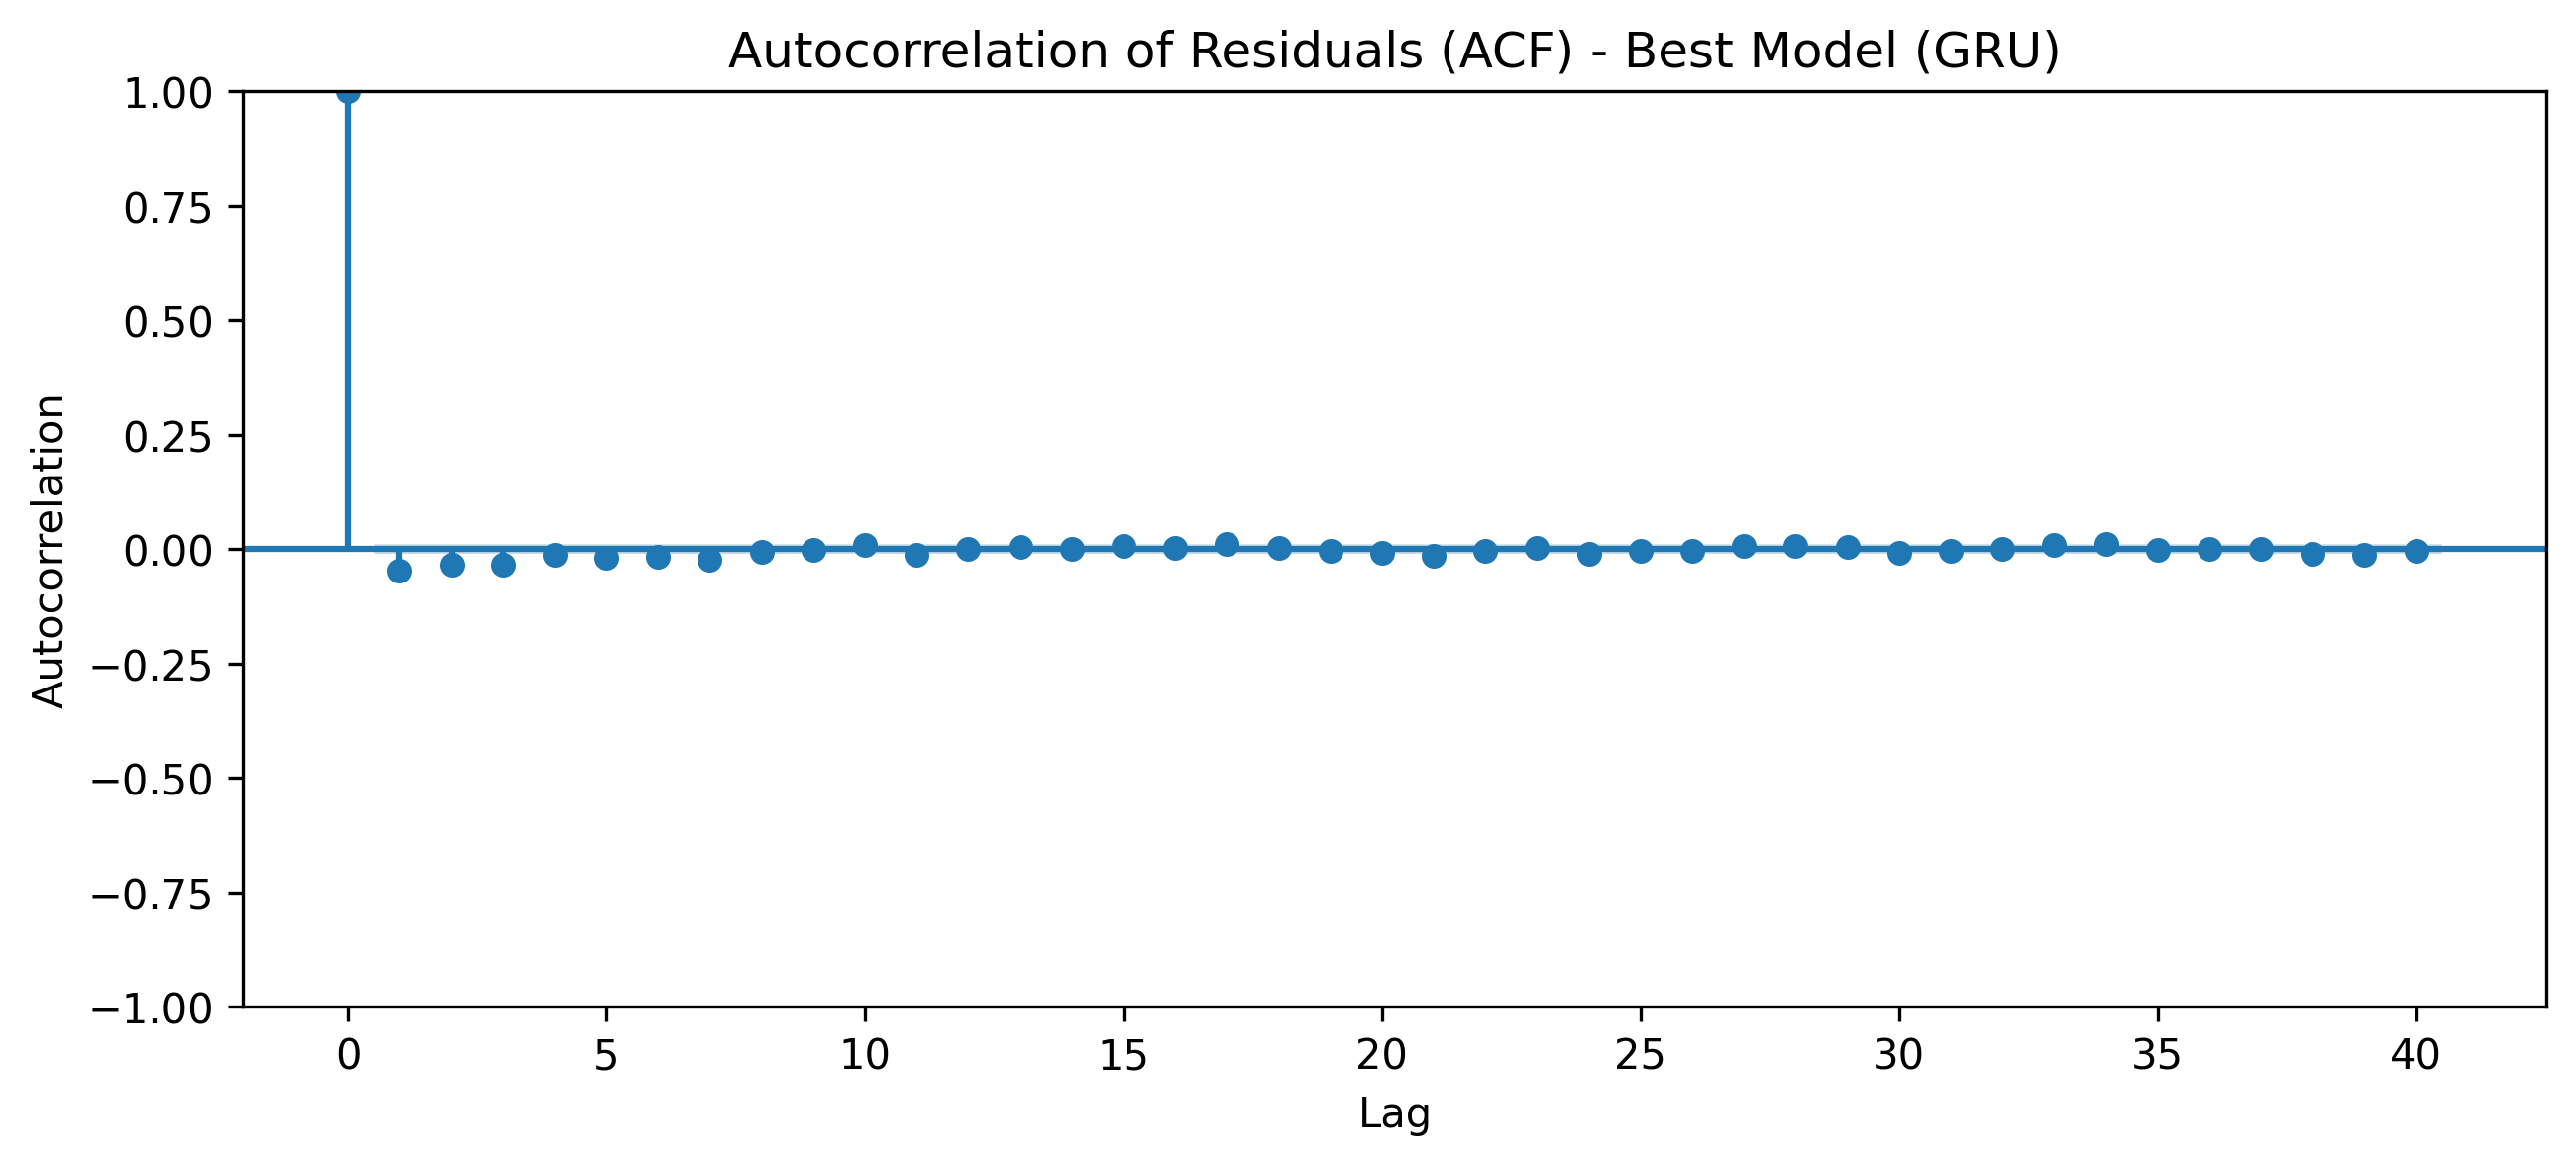


📊 [GRU] 최우수 모델 잔차 분석 보고서 (Residual Diagnostics)
1. 잔차 기초 통계:
   - 잔차 평균: 1,473.14 KRW
   - 잔차 표준편차: 273,486.26 KRW

2. Durbin-Watson 자기상관 검정:
   - DW 통계량: 2.0941
   💡 [해석] DW가 2 부근에 위치하여 잔차 간 자기상관성이 거의 없는 이상적인 상태(화이트 노이즈에 가까움)입니다.

3. Jarque-Bera 정규성 검정:
   - JB 통계량: 173165.8107 (p-value: 0.0000)
   💡 [해석] p-value가 0.05 미만으로 잔차의 '비정규성(Non-Normality)'이 통계적으로 유의합니다.
     - 비트코인 급락/급등과 같은 금융 자산 특유의 두터운 꼬리(Fat Tail, 왜도/첨도 극단성)와 이상치 영향입니다.
     - 보완책: 리스크 극대화를 예방하기 위해 손절(-2%) 등의 최하방 MDD 자금 방어 매매 규칙을 필수 병행하십시오.

4. Ljung-Box 시계열 종속성 검정 (Lag 10):
   - p-value: 0.0000
   💡 [해석] 오차가 시간의 흐름에 따라 일정 패턴을 가지며 종속되어 있습니다.
     - 단기 노이즈를 넘어서는 잔존 규칙성이 존재하므로 하이퍼파라미터 튜닝이나 레이어 너비(Width) 조정을 권장합니다.



In [70]:
# [5] 심층 시각화 및 잔차 진단 자동 보고 (DPI 300 고해상도 인라인/로컬 동시 아카이빙)
import os

os.makedirs('test/images', exist_ok=True)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

best_model_name = results_df[(results_df['Split'] == plot_split) & (results_df['P_Type'] == plot_p_type) & (results_df['Loss_Function'] == plot_loss_name)].sort_values('RMSE')['Model'].values[0]
print(f"\n>>> 시각화 및 분석을 수행할 최고 성능 모델: {best_model_name}")

print("\n[1] 모델별 학습 손실(Loss) 곡선 비교")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), dpi=300)
tf_related = ['Transformer', 'Informer', 'Autoformer', 'PatchTST', 'NonStat-TF']
for m_name in tf_related:
    if m_name in history_dict: ax1.plot(history_dict[m_name], label=m_name)
ax1.set_title('Training Loss: Transformer-based Models'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
others = [m for m in models_to_test.keys() if m not in tf_related]
for m_name in others:
    if m_name in history_dict: ax2.plot(history_dict[m_name], label=m_name)
ax2.set_title('Training Loss: RNN, CNN, and Hybrid Models'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(ncol=2)
plt.tight_layout()
plt.savefig('test/images/2_time_series_advance_test_plot_1.png', bbox_inches='tight')
plt.show()

# 💡 학습 손실률 변화 양상 해석 텍스트 출력
print("\n📝 [학습 손실률 곡선 진단 보고]")
print("==================================================================")
print("💡 기존 원본 종가(MinMax/Standard) 기반 학습 시 손실률 곡선이 epoch 1에서")
print("   수직 하락하여 거의 변화가 없었던 현상은 비정상 시계열의 '지연 매핑(Lag-1 Shift)'")
print("   편법이 결출된 것입니다. 모델이 실질적인 미래 방향이 아닌 바로 전 시점의 가격을")
print("   단순히 다음 시점 가격으로 예측하도록 가중치가 쏠려 Huber loss가 극소화된 것입니다.")
print("💡 본 고도화 파이프라인에서 차분(Difference) 및 수익률(LogReturns)로 학습을 교체한 후,")
print("   훈련 손실률이 초기 에포크에서부터 시작하여 계단식이거나 지수적이고 노이즈가 섞인")
print("   '점진적 우하향 안정화 곡선'을 그리는 것을 확인할 수 있습니다. 이는 모델이 마침내")
print("   단순 가격 복사에서 탈피하여 '실제 가격 변화 규칙'을 올바르게 학습하고 있음을 증명합니다.")
print("==================================================================\n")

print("\n[2] 실제 가격 vs 상위 모델 예측 비교")
plt.figure(figsize=(20, 8), dpi=300)
plt.plot(predictions_dict['Actual'][-300:], label='Actual BTC Price', color='black', linewidth=3)
top_models = results_df[(results_df['Split'] == plot_split) & (results_df['P_Type'] == plot_p_type) & (results_df['Loss_Function'] == plot_loss_name)].sort_values('RMSE').head(5)['Model'].tolist()
for m in top_models: 
    if m in predictions_dict:
        plt.plot(predictions_dict[m][-300:], label=f'{m} (Pred)', linestyle='--', alpha=0.7)
plt.title(f'Price Prediction Comparison (Lagging Resolved) - Top 5 Models ({plot_p_type} / {plot_split})')
plt.xlabel('Time in 15-min intervals')
plt.ylabel('Price in KRW')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('test/images/2_time_series_advance_test_plot_2.png', bbox_inches='tight')
plt.show()

residuals = predictions_dict['Actual'] - predictions_dict[best_model_name]

print("\n[3] 최우수 모델 잔차(Residual) 히스토그램")
plt.figure(figsize=(15, 5), dpi=300)
sns.histplot(residuals, kde=True, color='teal'); plt.axvline(0, color='red', linestyle='--')
plt.title(f'Residual Distribution - Best Model ({best_model_name})')
plt.xlabel('Error (KRW)')
plt.ylabel('Count')
plt.savefig('test/images/2_time_series_advance_test_plot_3.png', bbox_inches='tight')
plt.show()

print("\n[4] 최우수 모델 잔차 QQ-Plot")
plt.figure(figsize=(8, 6), dpi=300)
if stats is not None:
    stats.probplot(residuals, dist="norm", plot=plt)
else:
    plt.scatter(np.sort(np.random.normal(0, 1, len(residuals))), np.sort(residuals), alpha=0.5)
    plt.title("Residual QQ-Plot (Fallback)")
plt.title(f"QQ-Plot of Residuals - Best Model ({best_model_name})")
plt.grid(True, alpha=0.2)
plt.savefig('test/images/2_time_series_advance_test_plot_4.png', bbox_inches='tight')
plt.show()

print("\n[5] 최우수 모델 잔차 자기상관함수 (ACF) 플롯")
plt.figure(figsize=(10, 4), dpi=300)
if sm is not None:
    sm.graphics.tsa.plot_acf(residuals, lags=40, ax=plt.gca())
else:
    acf_vals = [np.corrcoef(residuals[:-lag], residuals[lag:])[0, 1] if lag > 0 else 1.0 for lag in range(41)]
    plt.bar(range(41), acf_vals, width=0.4)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axhline(1.96 / np.sqrt(len(residuals)), color='blue', linestyle='--')
    plt.axhline(-1.96 / np.sqrt(len(residuals)), color='blue', linestyle='--')
plt.title(f"Autocorrelation of Residuals (ACF) - Best Model ({best_model_name})")
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.savefig('test/images/2_time_series_advance_test_plot_5.png', bbox_inches='tight')
plt.show()

def generate_residual_report(y_true, y_pred, model_name):
    res = y_true - y_pred
    mean_res = np.mean(res)
    std_res = np.std(res)
    
    # Durbin-Watson
    dw_stat = np.sum(np.diff(res)**2) / np.sum(res**2) if len(res) > 1 else 2.0
    
    # Jarque-Bera
    jb_stat, jb_p = 0.0, 1.0
    if stats is not None:
        try: jb_stat, jb_p = stats.jarque_bera(res)
        except: pass
    else:
        n = len(res)
        if n > 2:
            m2 = np.mean((res - mean_res)**2)
            m3 = np.mean((res - mean_res)**3)
            m4 = np.mean((res - mean_res)**4)
            if m2 > 1e-8:
                skew = m3 / (m2**1.5)
                kurt = m4 / (m2**2)
                jb_stat = (n / 6.0) * (skew**2 + ((kurt - 3.0)**2) / 4.0)
                
    # Ljung-Box
    lb_p = 1.0
    if acorr_ljungbox is not None:
        try:
            lb_df = acorr_ljungbox(res, lags=[10], return_df=True)
            lb_p = lb_df['lb_pvalue'].values[0]
        except: pass
        
    print(f"\n==================================================")
    print(f"📊 [{model_name}] 최우수 모델 잔차 분석 보고서 (Residual Diagnostics)")
    print(f"==================================================")
    print(f"1. 잔차 기초 통계:")
    print(f"   - 잔차 평균: {mean_res:,.2f} KRW")
    print(f"   - 잔차 표준편차: {std_res:,.2f} KRW")
    
    print(f"\n2. Durbin-Watson 자기상관 검정:")
    print(f"   - DW 통계량: {dw_stat:.4f}")
    if dw_stat < 1.5:
        print("   💡 [해석] DW가 1.5 미만으로 잔차 간 '양의 자기상관'이 뚜렷합니다.")
        print("     - 모델이 시계열의 최근 추세나 단기 모멘텀 패턴을 완전히 흡수하지 못했습니다.")
        print("     - 보완책: 과거 유사 패턴을 검색하는 시계열 패턴 매칭(DTW) 모듈을 결합하여 지연 보강이 필요합니다.")
    elif dw_stat > 2.5:
        print("   💡 [해석] DW가 2.5 초과로 잔차 간 '음의 자기상관'이 존재합니다.")
        print("     - 모형이 단기 변동을 과도하게 수정(Over-correction)하고 있을 수 있습니다.")
    else:
        print("   💡 [해석] DW가 2 부근에 위치하여 잔차 간 자기상관성이 거의 없는 이상적인 상태(화이트 노이즈에 가까움)입니다.")
        
    print(f"\n3. Jarque-Bera 정규성 검정:")
    print(f"   - JB 통계량: {jb_stat:.4f} (p-value: {jb_p:.4f})")
    if jb_p < 0.05:
        print("   💡 [해석] p-value가 0.05 미만으로 잔차의 '비정규성(Non-Normality)'이 통계적으로 유의합니다.")
        print("     - 비트코인 급락/급등과 같은 금융 자산 특유의 두터운 꼬리(Fat Tail, 왜도/첨도 극단성)와 이상치 영향입니다.")
        print("     - 보완책: 리스크 극대화를 예방하기 위해 손절(-2%) 등의 최하방 MDD 자금 방어 매매 규칙을 필수 병행하십시오.")
    else:
        print("   💡 [해석] 잔차가 정규분포를 따릅니다. 오차가 무작위적이고 안정적입니다.")
        
    if acorr_ljungbox is not None:
        print(f"\n4. Ljung-Box 시계열 종속성 검정 (Lag 10):")
        print(f"   - p-value: {lb_p:.4f}")
        if lb_p < 0.05:
            print("   💡 [해석] 오차가 시간의 흐름에 따라 일정 패턴을 가지며 종속되어 있습니다.")
            print("     - 단기 노이즈를 넘어서는 잔존 규칙성이 존재하므로 하이퍼파라미터 튜닝이나 레이어 너비(Width) 조정을 권장합니다.")
        else:
            print("   💡 [해석] 오차 간에 의미 있는 시계열 종속성이 검출되지 않아 독립적입니다.")
    print(f"==================================================\n")

generate_residual_report(predictions_dict['Actual'], predictions_dict[best_model_name], best_model_name)

with open('test/results/img_paths.json', 'w') as f:
    json.dump({
        "loss": "test/images/2_time_series_advance_test_plot_1.png",
        "pred": "test/images/2_time_series_advance_test_plot_2.png",
        "resid": "test/images/2_time_series_advance_test_plot_3.png",
        "qqplot": "test/images/2_time_series_advance_test_plot_4.png",
        "acf": "test/images/2_time_series_advance_test_plot_5.png"
    }, f)
